# FTT (Feature Tokenizer-Transformer) clustering: Physiological Sepsis Phenotyping for 5-5min segments in Pitt Data 
## Stage 2: Data preprocessing and phenotype identification

# With limited dataset (when matched with target vectors)



In [ ]:
# rm -rf ~/.cache

In [ ]:
# %pip install scipy==1.11.4
# import tc_tabular_consensus_clusters_pipeline

In [ ]:
#### pip install scipy==1.9.3 #required for import scikitplot as skplt

In [1]:
import pandas as pd
from datetime import datetime
import os
import numpy as np
from scipy.io import loadmat
import glob
import json
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# Rest of the workflow is as follows:

In [ ]:
#
'''
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset

# ===== Step 1: Autoencoder Backbone =====
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        dims = [input_dim] + hidden_dims
        self.encoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.latent = nn.Linear(dims[-1], latent_dim)

    def forward(self, x):
        h = F.relu(self.encoder(x))
        z = self.latent(h)
        return z

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        dims = [latent_dim] + hidden_dims[::-1]
        self.decoder = nn.Sequential(*[nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.output = nn.Linear(dims[-1], output_dim)

    def forward(self, z):
        h = F.relu(self.decoder(z))
        return self.output(h)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dims, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dims, input_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

# ===== Step 2: Deep Embedded Clustering Module =====
class DEC(nn.Module):
    def __init__(self, ae, n_clusters):
        super().__init__()
        self.ae = ae
        self.n_clusters = n_clusters
        self.cluster_centers = nn.Parameter(torch.Tensor(n_clusters, ae.encoder.latent.out_features))
        nn.init.xavier_uniform_(self.cluster_centers.data)

    def target_distribution(self, q):
        weight = q ** 2 / q.sum(0)
        return (weight.t() / weight.sum(1)).t()

    def soft_assign(self, z):
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q / q.sum(1, keepdim=True)
        return q

    def forward(self, x):
        _, z = self.ae(x)
        q = self.soft_assign(z)
        return q, z

# ===== Step 3: Training =====
def train_dec(model, data_tensor, n_clusters=4, pretrain_epochs=20, dec_epochs=50, batch_size=64):
    dataloader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.ae.parameters(), lr=1e-3)

    # --- Pretrain Autoencoder ---
    for epoch in range(pretrain_epochs):
        for batch in dataloader:
            x = batch[0]
            x_hat, _ = model.ae(x)
            loss = F.mse_loss(x_hat, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- Initialize Clusters ---
    with torch.no_grad():
        latent = model.ae.encoder(data_tensor)
    kmeans = KMeans(n_clusters=n_clusters, n_init=20)
    model.cluster_centers.data.copy_(torch.tensor(kmeans.fit(latent.detach().numpy()).cluster_centers_))

    # --- Train DEC ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(dec_epochs):
        for batch in dataloader:
            x = batch[0]
            q, z = model(x)
            p = model.target_distribution(q.detach())
            loss_kl = F.kl_div(q.log(), p, reduction='batchmean')
            x_hat, _ = model.ae(x)
            loss_recon = F.mse_loss(x_hat, x)
            loss = loss_kl + loss_recon
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

# ===== Step 4: Usage Example =====
# Assume `X_tensor` is a torch.FloatTensor of shape (N, 87) with snapshot physiomarkers
# input_dim = 87
# hidden_dims = [64, 32]
# latent_dim = 10
# n_clusters = 4

# ae = Autoencoder(input_dim, hidden_dims, latent_dim)
# dec = DEC(ae, n_clusters)
# dec = train_dec(dec, X_tensor, n_clusters=n_clusters)
# dec


from sklearn.datasets import make_blobs
import torch
import numpy as np

# Parameters
n_samples = 300
n_features = 87  # same as your physiomarker count
n_clusters = 4   # for 4 phenotypes
random_state = 42

# Generate synthetic data
X_np, y_true = make_blobs(n_samples=n_samples, centers=n_clusters, 
                          n_features=n_features, cluster_std=1.5, random_state=random_state)

# Convert to PyTorch tensor
X_tensor = torch.tensor(X_np, dtype=torch.float32)

input_dim = n_features
hidden_dims = [64, 32]
latent_dim = 10
n_clusters = 4

ae = Autoencoder(input_dim, hidden_dims, latent_dim)
dec = DEC(ae, n_clusters)
dec = train_dec(dec, X_tensor, n_clusters=n_clusters)



from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
X_pca = PCA(n_components=2).fit_transform(X_np)

# Plot ground truth clusters
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=20)
plt.title("Simulated Physiophenotypes (Ground Truth)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

'''
# end

In [ ]:
AllSuperTable_1 = pd.read_csv('Data_folder/df_step1_physiomarkers_presepsis6hrs_5minWindow_new_v5.csv')
AllSuperTable_1.drop(columns=['Unnamed: 0'],axis=1,inplace=True)
AllSuperTable_1 

In [ ]:
AllSuperTable_perfect = AllSuperTable_1[AllSuperTable_1.status=='perfect']
AllSuperTable_perfect

In [ ]:
del AllSuperTable_1

In [ ]:
len(AllSuperTable_perfect.fin.unique()), len(AllSuperTable_perfect.studyID.unique())

In [ ]:
import seaborn as sns
sns.boxplot(AllSuperTable_perfect[['T_rr_ms_median', 'T_rr_ms_min', 'T_rr_ms_max']], showfliers=False)

In [ ]:
AllSuperTable_2 = AllSuperTable_perfect.drop_duplicates()
AllSuperTable_2.reset_index(drop=True, inplace=True)
AllSuperTable_2

In [ ]:
del AllSuperTable_perfect

In [ ]:
AllSuperTable_2[AllSuperTable_2.segmentID==0].shape, AllSuperTable_2[AllSuperTable_2.segmentID==0].fin.nunique()

In [ ]:
AllSuperTable_2.columns[:50]

In [ ]:
AllSuperTable_2.columns[50:]

In [ ]:
AllSuperTable_2.fin.nunique()

### Datatype handling

In [ ]:
import re
'''Curation of studyID column if it carries "XXXX.0" sort of entries'''
def clean_mixed_column(val):
    # Convert to string
    val_str = str(val)
    
    # If it matches float with .0 (e.g., 1308267.0 or '1308267.0')
    if re.match(r'^\d+\.0$', val_str):
        return val_str.split('.')[0]  # Remove .0
    else:
        return val_str

AllSuperTable_2['studyID'] = AllSuperTable_2['studyID'].apply(clean_mixed_column)

In [ ]:
AllSuperTable_2['fin'] = AllSuperTable_2['fin'].astype('int')
AllSuperTable_2['studyID'] = AllSuperTable_2['studyID'].astype('str')

In [ ]:
AllSuperTable_2['t_sepsis'] = pd.to_datetime(AllSuperTable_2['t_sepsis'])

## Add qSOFAs as feature variable: qSOFA_sbp, qSOFA_rr, qSOFA_gcs

GCS < 15, Respiratory rate ≥ 22, Systolic BP ≤ 100

In [ ]:
path = '../pitts_emr_data'

vitals_gcs = pd.read_csv(path + '/vitals_GCS_new.csv', low_memory=False)
vitals_rr = pd.read_csv(path + '/vitals_resp_rate.csv', low_memory=False)
vitals_sbp = pd.read_csv(path + '/vitals_sbp.csv', low_memory=False, on_bad_lines='skip')

In [ ]:
# with open(path + '/vitals_sbp_new.csv', 'r') as f:
#     for i, line in enumerate(f):
#         if 2607000 <= i <= 2607015:
#             print(f"Line {i}: {line}")

In [ ]:
# vitals4.shape, vitals7.shape, vitals8.shape

In [ ]:
vitals_gcs['fin'] = vitals_gcs.FIN_study_id.astype('int')
vitals_gcs['studyID'] = vitals_gcs.study_id.astype('str')
vitals_gcs['chartdate'] = pd.to_datetime(vitals_gcs['chartdate'])

vitals_rr['fin'] = vitals_rr.FIN_study_id.astype('int')
vitals_rr['studyID'] = vitals_rr.study_id.astype('str')
vitals_rr['chartdate'] = pd.to_datetime(vitals_rr['chartdate'])

vitals_sbp['fin'] = vitals_sbp.FIN_study_id.astype('int')
vitals_sbp['studyID'] = vitals_sbp.study_id.astype('str')
vitals_sbp['chartdate'] = pd.to_datetime(vitals_sbp['chartdate'])

In [ ]:
# v = [vitals4, vitals7, vitals8]
# v_matched = pd.DataFrame()
# for v_i in v:
#     v_i.reset_index(inplace=True, drop=True)
#     v_i['fin'] = v_i.FIN_study_id.values
#     v_i['studyID'] = v_i.study_id.values
#     v_i['chartdate'] = pd.to_datetime(v_i['chartdate'])
#     v_i_matched = AllSuperTable_2.merge(v_i[['fin','studyID','chartdate','result_val', 'result_unit', 
#                                  'Vitals']], on=['fin', 'studyID'], how='left')
#     v_i_matched = v_i_matched[~v_i_matched.Vitals.isnull()]
#     v_matched = pd.concat([v_matched, v_i_matched])
# v_matched.reset_index(inplace=True, drop=True)
# ## v_matched

In [ ]:
# v = [vitals4, vitals7, vitals8]
# v_concat = pd.concat(v)

# v_concat.reset_index(inplace=True, drop=True)
# v_concat['fin'] = v_concat.FIN_study_id.values
# v_concat['studyID'] = v_concat.study_id.values
# v_concat['chartdate'] = pd.to_datetime(v_concat['chartdate'])
# v_concat

# v_matched = AllSuperTable_2.merge(v_concat[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 # 'Vitals']], on=['fin'], how='left')

In [ ]:
vitals_gcs.fin.nunique(), vitals_rr.fin.nunique(), vitals_sbp.fin.nunique(), AllSuperTable_2.fin.nunique()

In [ ]:
vitals_gcs_matched = vitals_gcs[vitals_gcs.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_gcs_matched.shape

In [ ]:
vitals_rr_matched = vitals_rr[vitals_rr.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_rr_matched.shape

In [ ]:
vitals_sbp_matched = vitals_sbp[vitals_sbp.fin.isin(AllSuperTable_2.fin)].drop_duplicates()
vitals_sbp_matched.shape

In [ ]:
del vitals_gcs, vitals_rr, vitals_sbp
print("Unique FINs in AllSuperTable_2:", AllSuperTable_2['fin'].nunique())
print("Unique FINs in vitals_gcs_matched:", vitals_gcs_matched['fin'].nunique())
print("Unique FINs in vitals_rr_matched:", vitals_rr_matched['fin'].nunique())
print("Unique FINs in vitals_sbp_matched:", vitals_sbp_matched['fin'].nunique())

In [ ]:
v_matched_gcs = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_gcs_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_gcs.shape

In [ ]:
v_matched_rr = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_rr_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_rr.shape

In [ ]:
v_matched_sbp = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(vitals_sbp_matched[['fin','studyID','chartdate','result_val', 'result_unit', 
                                 'Vitals']], on=['fin'], how='inner').drop_duplicates()
v_matched_sbp.shape

In [ ]:
del vitals_gcs_matched, vitals_rr_matched, vitals_sbp_matched

In [ ]:
# grouped = v_matched.groupby('Vitals')
# qSOFA_gcs = grouped.get_group('GCS')[['studyID','fin','chartdate','result_val']]
# qSOFA_gcs = qSOFA_gcs[qSOFA_gcs.result_val!=' ']

In [ ]:
qSOFA_gcs = v_matched_gcs[['studyID_x','fin','chartdate','result_val']]
qSOFA_gcs['studyID'] = qSOFA_gcs['studyID_x'].astype('str')
qSOFA_gcs = qSOFA_gcs[qSOFA_gcs.result_val!=' ']
qSOFA_gcs['qSOFA_gcs'] = pd.Series(qSOFA_gcs['result_val'].astype('float') < 15, dtype=int)
qSOFA_gcs = qSOFA_gcs[['studyID', 'fin', 'chartdate', 'qSOFA_gcs']]
qSOFA_gcs.drop_duplicates(inplace=True)
qSOFA_gcs.reset_index(inplace=True, drop=True)

In [ ]:
qSOFA_rr1 = v_matched_rr[['studyID_x','fin','chartdate','result_val']]
qSOFA_rr1['studyID'] = qSOFA_rr1['studyID_x'].astype('str')
qSOFA_rr1 = qSOFA_rr1[qSOFA_rr1.result_val!=' ']
qSOFA_rr1['qSOFA_rr'] = pd.Series(qSOFA_rr1['result_val'].astype('float') >= 22, dtype=int)
qSOFA_rr1 = qSOFA_rr1[['studyID', 'fin', 'chartdate', 'qSOFA_rr']]
qSOFA_rr1.drop_duplicates(inplace=True)
qSOFA_rr1.reset_index(inplace=True, drop=True)
qSOFA_rr = qSOFA_rr1.copy()

In [ ]:
qSOFA_sbp1 = v_matched_sbp[['studyID_x','fin','chartdate','result_val']]
qSOFA_sbp1['studyID'] = qSOFA_sbp1['studyID_x'].astype('str')
qSOFA_sbp1 = qSOFA_sbp1[qSOFA_sbp1.result_val!=' ']
qSOFA_sbp1['qSOFA_sbp'] = pd.Series(qSOFA_sbp1['result_val'].astype('float') <= 100, dtype=int)
qSOFA_sbp1 = qSOFA_sbp1[['studyID', 'fin', 'chartdate', 'qSOFA_sbp']]
qSOFA_sbp1.drop_duplicates(inplace=True)
qSOFA_sbp1.reset_index(inplace=True, drop=True)
qSOFA_sbp = qSOFA_sbp1.copy()

In [ ]:
# qSOFA_dbp = grouped.get_group('dbp')[['studyID','fin','chartdate','result_val']]
# qSOFA_dbp['dbp'] = qSOFA_dbp.result_val.values
# qSOFA_dbp = qSOFA_dbp[qSOFA_dbp.result_val!=' ']
# qSOFA_dbp.reset_index(inplace=True, drop=True)
# qSOFA_dbp.drop(columns=['result_val'], inplace=True)

# qSOFA_map = grouped.get_group('map')[['studyID','fin','chartdate','result_val']]
# qSOFA_map['map'] = qSOFA_map.result_val.values
# qSOFA_map = qSOFA_map[qSOFA_map.result_val!=' ']
# qSOFA_map.reset_index(inplace=True, drop=True)
# qSOFA_map.drop(columns=['result_val'], inplace=True)

# qSOFA_map_dbp = qSOFA_map.merge(qSOFA_dbp, on=['studyID','fin','chartdate'], how='left')
# qSOFA_map_dbp = qSOFA_map_dbp[~qSOFA_map_dbp.dbp.isnull()]
# qSOFA_map_dbp['sbp'] = (3*qSOFA_map_dbp['map'].astype('float')) - (2*qSOFA_map_dbp['dbp'].astype('float'))
# qSOFA_map_dbp['qSOFA_sbp'] = pd.Series(qSOFA_map_dbp['sbp']<=100, dtype=int)
# qSOFA_sbp = qSOFA_map_dbp[['studyID', 'fin', 'chartdate', 'qSOFA_sbp']]
# qSOFA_sbp.drop_duplicates(inplace=True)
# qSOFA_sbp.reset_index(inplace=True, drop=True)


In [ ]:
AllSuperTable_2.fin.nunique(), qSOFA_sbp.fin.nunique(), qSOFA_rr.fin.nunique(), qSOFA_gcs.fin.nunique()

In [ ]:
sbp_rr = qSOFA_sbp.merge(qSOFA_rr, on=['studyID', 'fin', 'chartdate'], how='left')
sbp_rr_gcs = sbp_rr.merge(qSOFA_gcs, on=['studyID', 'fin', 'chartdate'], how='left')
sbp_rr_gcs.drop_duplicates(inplace=True)
sbp_rr_gcs.columns, sbp_rr_gcs.shape

In [ ]:
AllSuperTable_wqSOFA = AllSuperTable_2[['studyID', 'fin', 'segmentID', 't_sepsis']].merge(sbp_rr_gcs, on=['studyID', 'fin'], how='left')
#AllSuperTable_wqSOFA = AllSuperTable_wqSOFA[~AllSuperTable_wqSOFA.qSOFA_total.isnull()]

In [ ]:
AllSuperTable_wqSOFA

In [ ]:
AllSuperTable_2[['fin','segmentID']].drop_duplicates().shape, AllSuperTable_2.shape, #AllSuperTable_wqSOFA.fin.nunique()

In [ ]:
# for individual encounter/fin and a given segmentID
def qSOFA_nearest_to_segment(df):
    df['diff_date'] = df['chartdate'] - df['t_sepsis'] - (df['segmentID']*pd.Timedelta('0 days 00:05:00'))
    if df[['qSOFA_sbp','qSOFA_rr','qSOFA_gcs']].isnull().all().all():
        mf = df.iloc[0]
    else: 
        if (df['diff_date']>=pd.Timedelta(0)).all(): # if all true
            minD = df['diff_date'].min() #Latest to tsepsis
        else:
            minD = df['diff_date'][df['diff_date']<pd.Timedelta(0)].max() #Latest to tsepsis
        mf = df.iloc[np.where(df['diff_date']==minD)[0][0]]
    return mf    

In [ ]:
df_all = pd.DataFrame([])
for i in tqdm(range(AllSuperTable_2.shape[0])):
    fin_i = AllSuperTable_2.iloc[i]['fin']
    segmentID_i = AllSuperTable_2.iloc[i]['segmentID']
    df_fin = AllSuperTable_wqSOFA[AllSuperTable_wqSOFA.fin==fin_i]
    df_fin = df_fin.ffill()
    df_fin = df_fin.bfill()
    df_fin_seg = df_fin[df_fin.segmentID==segmentID_i]
    df_row = pd.DataFrame(qSOFA_nearest_to_segment(df_fin_seg)).T
    df_all = pd.concat([df_all, df_row])

In [ ]:
df_all.reset_index(inplace=True, drop=True)
df_all['qSOFA_total'] = df_all['qSOFA_sbp'] + df_all['qSOFA_rr'] + df_all['qSOFA_gcs'] 
df_all_2 = df_all[['studyID','fin','segmentID','t_sepsis','qSOFA_sbp','qSOFA_rr','qSOFA_gcs','qSOFA_total']]
df_all_2

In [ ]:
df_all_2['t_sepsis'] = pd.to_datetime(df_all_2['t_sepsis'])
df_all_2.qSOFA_total.isnull().sum(), df_all_2.qSOFA_total.value_counts()

In [ ]:
AllSuperTable_2new = AllSuperTable_2.merge(df_all_2, on=['studyID','fin','segmentID','t_sepsis'], how='left')

In [ ]:
AllSuperTable_2new

In [ ]:
AllSuperTable_2new.drop(columns = ['status'], axis=1, inplace=True)

In [ ]:
AllSuperTable_2new.columns

In [ ]:
AllSuperTable_2new[~AllSuperTable_2new.qSOFA_gcs.isnull()].fin.nunique()

In [ ]:
AllSuperTable_2new.columns[7:]

# Outlier Rejection: using IQR method (considering non-normal nature of feature data)

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum()

In [ ]:
AllSuperTable_2new.DN_exists.isnull().sum()

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,:32]

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,32:50]

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,50:85]

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,85:100]

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].describe().iloc[:,100:]

In [ ]:
AllSuperTable_2new.T_rr_ms_mean.plot()

In [ ]:
AllSuperTable_2new.qSOFA_total.plot()

In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum(), AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].shape

In [ ]:
AllSuperTable_2new = AllSuperTable_2new.replace([np.inf, -np.inf], np.nan)
# AllSuperTable_2['hrv_dfa_alpha2'] = AllSuperTable_2['hrv_dfa_alpha2'].apply(lambda x: np.nan if x == '[]' else x).astype(float)


In [ ]:
AllSuperTable_2new.columns[9:]

In [ ]:
'''
Don't do the outlier-rejection in categorial and ordinal numeric variables

DN_exists, ppg_class, qSOFA_xx
'''
for i in AllSuperTable_2new.loc[:,'T_rr_ms_mean':'ShockIndex_valid_n'].columns: #ShockIndex
    if (i!='DN_exists') and (i!='ppg_class'):
        print(i)
        percentile25 = AllSuperTable_2new[i].quantile(0.25)
        percentile75 = AllSuperTable_2new[i].quantile(0.75)
        iqr = percentile75 - percentile25
        upper_limit = percentile75 + 1.5 * iqr
        lower_limit = percentile25 - 1.5 * iqr
        
        ### METHODS: Trimming or Caping or Replacing by nans
        ### Selected "Replacing by nans" method  
        uL = np.where(AllSuperTable_2new[i] > upper_limit)[0]
        lL = np.where(AllSuperTable_2new[i] < lower_limit)[0]
        
        AllSuperTable_2new.loc[uL,i] = np.nan
        AllSuperTable_2new.loc[lL,i] = np.nan



In [ ]:
AllSuperTable_2new.loc[:,'T_rr_ms_mean':'qSOFA_total'].isnull().sum().sum()

In [ ]:
AllSuperTable_2new.T_rr_ms_mean.plot()

In [ ]:
AllSuperTable_2new.reset_index(inplace=True, drop=True)
AllSuperTable_2new.shape

In [ ]:
# df_Sepsis_demo.reset_index(inplace=True, drop=True)

In [ ]:
AllSuperTable_2new.columns[:100]

In [ ]:
AllSuperTable_2new.columns[100:200]

In [ ]:
AllSuperTable_2new.columns[200:]

In [ ]:
df_Sepsis_final = AllSuperTable_2new.copy()



# [['waveID', 'fin', 'segmentID', 'year_sepsis', 'studyID', 't_origin',
#        't_sepsis', 'sofa', 'DN_exists', 'ppg_class', 'T_rr_ms', 'HR_bpm', 'edr_rate_Bpm',
#        'atrialSys_phase', 'ventSys_phase', 'P_duration', 'QRS_duration',
#        'T_duration', 'pr_interval_ms', 'pr_segment_ms', 'st_interval_ms',
#        'st_segment_ms', 'qt_interval_ms', 'qtc_interval_ms',
#        'ecgBeatCenterFreq', 'ecgInterbeat_eigval1', 'ecgInterbeat_eigval2',
#        'ecgInterbeat_eigval3', 'HRV_rqa_REC', 'HRV_rqa_DET', 'HRV_rqa_LAM',
#        'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
#        'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
#        'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
#        'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
#        'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
#        'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
#        'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2',
#        'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP',
#        'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI',
#        'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d',
#        'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd',
#        'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width',
#        'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean',
#        'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta',
#        'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Fluctuation', 
#        'HRV_MFDFA_alpha1_Increment', 'HRV_DFA_alpha2',
#        'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak',
#        'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max',
#        'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry',
#        'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment',
#        'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn',
#        'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC',
#        'MSE_0', 'MSE_1', 'MSE_2', 'MSE_3', 'MSE_4', 'MSE_5', 'MSE_6', 'MSE_7',
#        'MSE_8', 'MSE_9', 'MSE_10', 'MSE_11', 'MSE_12', 'MSE_13', 'MSE_14',
#        'MSE_15', 'MSE_16', 'MSE_17', 'MSE_18', 'MSE_19', 'AUC_pulse_nu',
#        'AUC_sys_nu', 'AUC_dias_nu', 'IPA', 'AUCow_nu', 'AUCwo_nu', 'AUCos_nu',
#        'AUCso_nu', 'Tsys_ms', 'Tdias_ms', 'T_ow_ms', 'T_wo_ms', 'T_os_ms',
#        'T_so_ms', 'T_so_cd_ms', 'A_AC', 'A_off', 'A_sp', 'A_dn',
#        'Ton_off_ms', 'Tsp_sp_ms', 'PR', 'mean_slope_os', 'mean_slope_so',
#        'Delta_T_sd', 'RI', 'SI', 'Delta_A_dn_dp', 'T_dn_dp_ms',
#        'max_upslope', 'pat_ms', 'dpat_ms', 'Delta_A_sp_sp',
#        'Augmentation_index', 'center_freq_ppg_Hz', 'mean_ppg', 'median_ppg',
#        'variance_ppg', 'skewness_ppg', 'kurtosis_ppg', 'std_ppg',
#        'entropy_ppg', 'energy_ppg', 'PW_10', 'PW_25', 'PW_33', 'PW_50',
#        'PW_66', 'PW_75', 'ppgBeatCenterFreq', 'ppgInterbeat_eigval1',
#        'ppgInterbeat_eigval2', 'ppgInterbeat_eigval3', 'insp_time', 'exp_time',
#        'insp_exp_ratio', 'resp_width_PPresp_s', 'resp_rate_Bpm', 'qSOFA_sbp', 'qSOFA_rr',
#        'qSOFA_gcs', 'qSOFA_total', 'SBP', 'DBP', 'HR_ABP', 
#        'MAP', 'PP_ABP', 'CO', 'TPR','ShockIndex']]
       
       

In [ ]:
df_Sepsis_final

In [ ]:
# df_Sepsis_demo['csn'].equals(df_Sepsis_final['csn'])

In [ ]:
df_Sepsis_final.ppg_class.unique()

# Step 1: Data Preprocessing (unimputed data)

In [ ]:
df_Sepsis_final.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
# pip install seaborn

In [ ]:
# df_Sepsis_final.shape, len(df_Sepsis_final.waveID.unique()), len(df_Sepsis_final.csn.unique()), len(df_Sepsis_final.pat_id.unique()), df_Sepsis_final.year.unique()



In [ ]:
df_Sepsis_final.columns

In [ ]:
df_Sepsis_final.loc[:,'T_rr_ms_mean':].isnull().sum()

In [ ]:
df_Sepsis_final.DN_exists.value_counts()

In [ ]:
AllSuperTable_2[AllSuperTable_2.T_rr_ms_median.isnull()][['index','T_rr_ms_median','edr_rate_Bpm_median','Tsp_sp_ms_median']]

## Rejection of Features: Check the missingness (%) for every variables: discard if >85%

In [ ]:
ix_list = []
indx = list(df_Sepsis_final.columns).index('T_rr_ms_mean')
for ix, i in enumerate(df_Sepsis_final.columns[indx:]):
    missing_percent = np.round(100*df_Sepsis_final[i].isnull().sum()/len(df_Sepsis_final),2)
    if missing_percent >= 85:
        ix_list.append(indx+ix)
    print(i+':  ', missing_percent,'%')
df_Sepsis_final.columns[ix_list]

In [ ]:
list(df_Sepsis_final.columns[ix_list])

In [ ]:
'''
All avove >85% missing features are from ABP,
Let's not discard them for now. Maybe we can create a subcohort for similar study


Missingness variables: df_Sepsis_final.columns[ix_list]
'''






# df_Sepsis_final.drop(df_Sepsis_final.columns[ix_list], axis=1, inplace=True)
df_Sepsis_final.drop(list(df_Sepsis_final.columns[ix_list]), axis=1, inplace=True)

## Rejection of Patients: Check the missingness (%) for all patients: discard if >80%

In [ ]:
pat_ix = np.where(100*df_Sepsis_final.loc[:,'T_rr_ms_mean':].T.isnull().sum()/len(df_Sepsis_final.loc[:,'T_rr_ms_mean':].columns) > 80)
pat_ix

In [ ]:
pd.Series(100*df_Sepsis_final.loc[:,'T_rr_ms_mean':].T.isnull().sum()/len(df_Sepsis_final.loc[:,'T_rr_ms_mean':].columns)).describe()

In [ ]:
len(pat_ix[0]), df_Sepsis_final.iloc[pat_ix[0]].fin.nunique()

In [ ]:
df_Sepsis_final.iloc[pat_ix[0]]

In [ ]:
4806-4041

In [ ]:
df_Sepsis_final.drop(pat_ix[0], axis=0, inplace=True)

In [ ]:
df_Sepsis_final.loc[0,'T_rr_ms_mean':].isnull().sum()

In [ ]:
df_Sepsis_final.shape,  df_Sepsis_final.fin.nunique(), df_Sepsis_final.studyID.nunique()

In [ ]:
df_Sepsis_unimputed = df_Sepsis_final.copy()
df_Sepsis_unimputed.reset_index(drop=True, inplace=True)
df_Sepsis_unimputed

In [ ]:
len(df_Sepsis_unimputed.studyID.unique()), len(df_Sepsis_unimputed.fin.unique())

In [ ]:
df_Sepsis_unimputed.columns[10:29], df_Sepsis_unimputed.columns[100:]

# Imputation Scheme
- Level 1: For a same patient fin, do ffill then bfill for missing entries 
- Level 2: Then, perform median imputation after that

In [ ]:
df_Sepsis_unimputed.loc[:, list(df_Sepsis_unimputed.loc[:, 'T_rr_ms_mean':'qSOFA_total'].columns)] 
                        #+ list(df_Sepsis_unimputed.loc[:, 'mse20_1':'mse20_20'].columns)]

In [ ]:
from tc_MissingnessReport import missingness_report

In [ ]:
# Example DataFrame with artificial missingness
df = pd.DataFrame({
    'heart_rate': [75, 80, np.nan, 70, 65, np.nan, 90],
    'resp_rate': [np.nan]*7,
    'spo2': [98, 97, 99, np.nan, 96, 95, 94],
    'age': [60, 55, 70, 65, np.nan, 75, 68],
    'lactate': [np.nan, 1.2, 1.1, np.nan, np.nan, 2.0, 1.4]
})

report = missingness_report(df)
df

In [ ]:
df_report = missingness_report(df_Sepsis_unimputed.loc[:,'T_rr_ms_mean':'qSOFA_total']).iloc[:50]
df_report

## Final Discard variables having >15% of missingness, and then perform ffill-MICE-mixed imputation

In [ ]:
remove_list = list(df_report[df_report['Missing %']>=15].index)
len(remove_list), remove_list

In [ ]:
df_Sepsis_unimputed.drop(columns=remove_list, inplace=True)
df_Sepsis_unimputed

In [ ]:
df_Sepsis_unimputed.loc[:, list(df_Sepsis_unimputed.loc[:, 'T_rr_ms_mean':].columns)].isnull().sum().sum()  
     

In [ ]:
df_Sepsis_unimputed.columns[9:]

In [ ]:
col_to_move = 'DN_exists'
new_position = 10

# Get a list of columns
cols = df_Sepsis_unimputed.columns.tolist()

# Remove the column to move and insert it at the new position
cols.insert(new_position, cols.pop(cols.index(col_to_move)))

# Reorder DataFrame
df_Sepsis_unimputed = df_Sepsis_unimputed[cols]

In [ ]:
col_to_move = 'ppg_class'
new_position = 10

# Get a list of columns
cols = df_Sepsis_unimputed.columns.tolist()

# Remove the column to move and insert it at the new position
cols.insert(new_position, cols.pop(cols.index(col_to_move)))

# Reorder DataFrame
df_Sepsis_unimputed = df_Sepsis_unimputed[cols]

In [ ]:
df_Sepsis_unimputed.columns[9:]

In [ ]:
column_list_to_impute = list(df_Sepsis_unimputed.loc[:,'T_rr_ms_mean':].columns)
len(column_list_to_impute)

In [ ]:
column_list_to_impute

In [ ]:
from tc_Missingness_Imputation import mice_numeric_impute, timeseries_impute, median_numeric_impute

In [ ]:
df_Sepsis_imputed1 = timeseries_impute(df_Sepsis_unimputed, pat_enc_id='fin', column_list_to_impute=column_list_to_impute)

In [ ]:
# df_Sepsis_imputed2 = mice_impute(df_Sepsis_imputed1, column_list_to_impute, verbose=2)

In [ ]:
df_Sepsis_imputed1[df_Sepsis_imputed1.qSOFA_gcs.isnull()]

In [ ]:
# df_Sepsis_imputed2[['T_rr_ms','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

In [ ]:
df_Sepsis_imputed1[['T_rr_ms_mean','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

In [ ]:
df_Sepsis_unimputed.qSOFA_gcs.value_counts()

### Unsatisfied with MICE for whole mixed data

### Instead MICE-binary, MICE-ordinal, MICE-linear are used now

In [ ]:
from tc_Missingness_Imputation import mice_mixed_type_data_impute

In [ ]:
column_list_to_impute = list(df_Sepsis_imputed1.loc[:,'T_rr_ms_mean':].columns)
print(len(column_list_to_impute))
# df_Sepsis_mice_mixed_imputed =  mice_mixed_type_data_impute(df_Sepsis_imputed1, column_list_to_impute=column_list_to_impute)

In [ ]:
df_Sepsis_imputed2_median = median_numeric_impute(df_Sepsis_imputed1, column_list_to_impute)
df_Sepsis_imputed2_median

In [ ]:
df_Sepsis_imputed2_median[['T_rr_ms_mean','qSOFA_sbp','qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total']].describe()

In [ ]:
df_Sepsis_imputed2_median.qSOFA_total.value_counts(), df_Sepsis_imputed2_median.qSOFA_sbp.value_counts()

In [ ]:
# from tqdm import tqdm   ### Perform for the same patient
# df_Sepsis_imputed1 = pd.DataFrame([])
# for i in tqdm(df_Sepsis_unimputed.fin.unique()):
#     df_i = df_Sepsis_unimputed[df_Sepsis_unimputed.fin==i]
#     dfA_i = df_i.loc[:,:'ppg_class']
#     # dfB_i = df_i.loc[:,'T_rr_ms':'resp_rate_Bpm']
#     dfB_i = df_i.loc[:, list(df_i.loc[:, 'T_rr_ms':'qSOFA_total'].columns)]# + 
#                         #list(df_i.loc[:, 'mse20_1':'mse20_20'].columns)] #Avoiding ABP features
#     dfC_i = df_i.loc[:,'SBP':'ShockIndex']
#     dfB_i.fillna(method='ffill', inplace=True) 
#     dfB_i.fillna(method='bfill', inplace=True) 
#     dfABC_i = pd.concat([dfA_i, dfB_i, dfC_i], axis=1)
#     df_Sepsis_imputed1 = pd.concat([df_Sepsis_imputed1, dfABC_i], axis=0)
# df_Sepsis_imputed1.loc[:,'T_rr_ms':'qSOFA_total'].isnull().sum().sum()


In [ ]:
list(df_Sepsis_unimputed.columns[:13])

In [ ]:
col_list = list(df_Sepsis_unimputed.columns[1:12]) + list(df_Sepsis_imputed1.loc[:,'T_rr_ms_mean':].columns)
len(col_list)

In [ ]:
df_Sepsis_latest = df_Sepsis_imputed2_median[col_list].drop_duplicates()

In [ ]:
df_Sepsis_latest

In [ ]:
df_Sepsis_latest['qSOFA_total'].value_counts()

In [ ]:
df_Sepsis_latest['qSOFA_gcs'] = df_Sepsis_latest['qSOFA_gcs'].astype(int)
df_Sepsis_latest['qSOFA_rr'] = df_Sepsis_latest['qSOFA_rr'].astype(int)
df_Sepsis_latest['qSOFA_sbp'] = df_Sepsis_latest['qSOFA_sbp'].astype(int)
df_Sepsis_latest['qSOFA_total'] = df_Sepsis_latest['qSOFA_total'].astype(int)

# Step 2: After imputation

In [2]:
# df_Sepsis_latest.to_csv('Data_folder/df_step2_TS_pitts_sepsis3_ffillMedian_imputed_physiomarkers_2016-2022_new_v7.csv')
# df_Sepsis_unimputed.to_csv('Data_folder/df_step2_TS_pitts_sepsis3_rawUnimputed_physiomarkers_2016-2022_new_v7.csv')













df_Sepsis_latest = pd.read_csv('Data_folder/df_step2_TS_pitts_sepsis3_ffillMedian_imputed_physiomarkers_2016-2022_new_v7.csv')
df_Sepsis_unimputed = pd.read_csv('Data_folder/df_step2_TS_pitts_sepsis3_rawUnimputed_physiomarkers_2016-2022_new_v7.csv')


In [3]:
df_Sepsis_latest['studyID'] = df_Sepsis_latest.studyID.astype('str')
df_Sepsis_latest['fin'] = df_Sepsis_latest.fin.astype('int')
df_Sepsis_latest['t_sepsis'] = pd.to_datetime(df_Sepsis_latest['t_sepsis'])

In [ ]:
df_Sepsis_latest.segmentID.hist(bins=150, figsize=(12,5))
plt.xlabel('Segments from sepsis-3 time each of 5 min.')
plt.ylabel('Count of patients having waveforms')
plt.xlim([-1, 72])
plt.xticks(np.arange(72), size=7)
plt.show()

# Step 3: Map with target variables (Short term mortality, VPFD, VFD, ICU LOS)

In [ ]:
df_Sepsis_latest.fin.nunique(), df_Sepsis_latest.studyID.nunique(), df_Sepsis_latest.shape

In [ ]:
df_Sepsis_latest['t_sepsis'] = pd.to_datetime(df_Sepsis_latest.t_sepsis)

In [ ]:
# ==== Short term Septic shock Status ==== 

df_SShock = pd.read_csv('Data_folder/Event_Table/septicShock_encounters_final_Pitt.csv')
df_SShock['studyID'] = df_SShock.StudyID.astype('str')
df_SShock['fin'] = df_SShock.FIN.astype('int')
df_SShock.drop_duplicates(inplace=True)
df_SShock.reset_index(inplace=True, drop=True)

df_SShock['earliest_VP_On'] = pd.to_datetime(df_SShock['earliest_VP_On'])
df_SShock['earliest_lacticAcid>2'] = pd.to_datetime(df_SShock['earliest_lacticAcid>2'])
# Create SS_time as the maximum of the two
df_SShock['SS_time'] = df_SShock[['earliest_VP_On', 'earliest_lacticAcid>2']].max(axis=1)
df_SShock = df_SShock[['studyID','fin','SS_time']]
df_SShock['SS'] = True
df_SShock.shape

In [ ]:
### For SS Analysis Table

df_Sepsis_latest_SS = df_Sepsis_latest.merge(df_SShock, on=['fin'], how='left')
df_Sepsis_latest_SS['SS_time'] = pd.to_datetime(df_Sepsis_latest_SS.SS_time)
df_Sepsis_latest_SS[df_Sepsis_latest_SS.SS.isnull()] = False
print(df_Sepsis_latest_SS.SS.unique(), df_Sepsis_latest_SS.SS.isnull().sum(), df_Sepsis_latest_SS.shape)

### s_SS_Xd_final: Descriptive short-term SS table patient encounter wise.

s_SS = df_Sepsis_latest_SS[['fin','t_sepsis','SS_time','SS']].drop_duplicates()
s_SS.reset_index(drop=True, inplace=True)

def SS_X_days(df, Xdays=28):
    df['SS_time'] = pd.to_datetime(df['SS_time'], errors='coerce')
    df['t_sepsis'] = pd.to_datetime(df['t_sepsis'], errors='coerce')
    delT_sep_SS = (df['SS_time']-df['t_sepsis']).dt.days #SS day would be 100% after the sepsis3 time
    delT_sep_SS[delT_sep_SS>Xdays] = np.nan
    delT_sep_SS[df['SS']==False] = np.nan
    df['delT_sep_SS'] = delT_sep_SS
    s_SS_Xd = df[~df['delT_sep_SS'].isnull()]
    s_SS_Xd['day_postS3'] = s_SS_Xd['delT_sep_SS'].astype(int)
    s_SS_Xd[f'SS_{Xdays}'] = s_SS_Xd['SS'].astype(int)
    s_SS_Xd_final = s_SS_Xd[['fin','day_postS3',f'SS_{Xdays}']]
    s_SS_Xd_final.reset_index(drop=True, inplace=True)
    print(s_SS_Xd_final.head(), s_SS_Xd_final.shape, s_SS_Xd_final.fin.nunique())
    return s_SS_Xd_final

df = s_SS.copy()
s_SS_28d_final = SS_X_days(df, Xdays=28)
s_SS_7d_final = SS_X_days(df, Xdays=7)
s_SS_2d_final = SS_X_days(df, Xdays=2)
s_SS_1d_final = SS_X_days(df, Xdays=1)


s_SS_28_7d = s_SS_28d_final.merge(s_SS_7d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d = s_SS_28_7d.merge(s_SS_2d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d_1d = s_SS_28_7_2d.merge(s_SS_1d_final, how='left', on=['fin','day_postS3'])
s_SS_28_7_2d_1d.loc[:,'SS_7'][s_SS_28_7_2d_1d['SS_7'].isnull()] = 0
s_SS_28_7_2d_1d.loc[:,'SS_2'][s_SS_28_7_2d_1d['SS_2'].isnull()] = 0
s_SS_28_7_2d_1d.loc[:,'SS_1'][s_SS_28_7_2d_1d['SS_1'].isnull()] = 0
s_SS_28_7_2d_1d['SS_7'] = s_SS_28_7_2d_1d['SS_7'].astype(int)
s_SS_28_7_2d_1d['SS_2'] = s_SS_28_7_2d_1d['SS_2'].astype(int)
s_SS_28_7_2d_1d['SS_1'] = s_SS_28_7_2d_1d['SS_1'].astype(int)
s_SS_28_7_2d_1d = s_SS_28_7_2d_1d.drop_duplicates()
s_SS_28_7_2d_1d.reset_index(inplace=True, drop=True)
s_SS_28_7_2d_1d


In [ ]:
# ==== Short term mortality =====


demo = pd.read_csv('Data_folder/Event_Table/tcdemographics_mladi24_new.csv')
demo['studyID'] = demo.study_id.astype('str')
demo['fin'] = demo.FIN_study_id.astype('int')
demo.drop_duplicates(inplace=True)
demo.reset_index(inplace=True, drop=True)
death = demo.disch_disp.str.contains('CTB')
demo['death'] = death.values
demo.loc[:,'death'][demo.death.isnull()] = False

# # For Creating Demographics Table One 
# s_demographic = demo[demo.fin.isin(df_Sepsis_latest.fin)].drop_duplicates(subset='studyID',keep='first')
# s_demographic.reset_index(inplace=True, drop=True)
# s_demographic.columns, s_demographic.shape


In [ ]:
### For Mortality Analysis Table

df_Sepsis_latest_demo = df_Sepsis_latest.merge(demo, on=['fin'], how='left') #Just to carry demographic data as well
df_Sepsis_latest_demo['disch_date'] = pd.to_datetime(df_Sepsis_latest_demo.disch_date)
df_Sepsis_latest_demo.loc[:,'death'][df_Sepsis_latest_demo.death.isnull()] = False
print(df_Sepsis_latest_demo.death.unique(), df_Sepsis_latest_demo.death.isnull().sum(), df_Sepsis_latest_demo.shape)

### s_death_Xd_final: Descriptive short-term mortality/death table patient encounter wise.

s_death = df_Sepsis_latest_demo[['fin','t_sepsis','disch_date','death']].drop_duplicates()
s_death.reset_index(drop=True, inplace=True)

def STM_X_days(df, Xdays=28):
    delT_sep_death = (df['disch_date']-df['t_sepsis']).dt.days #Death day would be 100% after the sepsis3 time
    delT_sep_death[delT_sep_death>Xdays] = np.nan
    delT_sep_death[df['death']==False] = np.nan
    df['delT_sep_death'] = delT_sep_death
    s_death_Xd = df[~df['delT_sep_death'].isnull()]
    s_death_Xd['day_postS3'] = s_death_Xd['delT_sep_death'].astype(int)
    s_death_Xd[f'death_{Xdays}'] = s_death_Xd['death'].astype(int)
    s_death_Xd_final = s_death_Xd[['fin','day_postS3',f'death_{Xdays}']]
    s_death_Xd_final.reset_index(drop=True, inplace=True)
    print(s_death_Xd_final.head(), s_death_Xd_final.shape, s_death_Xd_final.fin.nunique())
    return s_death_Xd_final

df = s_death.copy()
s_death_28d_final = STM_X_days(df, Xdays=28)
s_death_7d_final = STM_X_days(df, Xdays=7)
s_death_2d_final = STM_X_days(df, Xdays=2)
s_death_1d_final = STM_X_days(df, Xdays=1)

s_death_28_7d = s_death_28d_final.merge(s_death_7d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d = s_death_28_7d.merge(s_death_2d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d_1d = s_death_28_7_2d.merge(s_death_1d_final, how='left', on=['fin','day_postS3'])
s_death_28_7_2d_1d.loc[:,'death_7'][s_death_28_7_2d_1d['death_7'].isnull()] = 0
s_death_28_7_2d_1d.loc[:,'death_2'][s_death_28_7_2d_1d['death_2'].isnull()] = 0
s_death_28_7_2d_1d.loc[:,'death_1'][s_death_28_7_2d_1d['death_1'].isnull()] = 0
s_death_28_7_2d_1d['death_7'] = s_death_28_7_2d_1d['death_7'].astype(int)
s_death_28_7_2d_1d['death_2'] = s_death_28_7_2d_1d['death_2'].astype(int)
s_death_28_7_2d_1d['death_1'] = s_death_28_7_2d_1d['death_1'].astype(int)
s_death_28_7_2d_1d = s_death_28_7_2d_1d.drop_duplicates()
s_death_28_7_2d_1d.reset_index(inplace=True, drop=True)
s_death_28_7_2d_1d

In [ ]:

# ==== Vasopressor-free days (VPFD) ====

# The number of days a patient survives and remains without requiring the use of vasopressor medications.
# Procedure: VPFD are typically counted as the number of consecutive days a patient is alive and does not require vasopressor therapy.
# VPFD = 0, if patient died within 28 days window.
df_VP = pd.read_csv('Data_folder/Event_Table/sepsis_all_VP_Before28D.csv')
df_VP.drop(df_VP.columns[df_VP.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_VP['studyID'] = df_VP['studyID'].astype('str')
df_VP['fin'] = df_VP['fin'].astype('int')
df_VP['T_vp_postS3'] = pd.to_datetime(df_VP['T_vp_postS3'])
df_VP['t_sepsis'] = pd.to_datetime(df_VP['t_sepsis'])
print(df_VP.columns, df_VP.shape)


### For VPFD Analysis Table on patient encounter level
df_s = df_Sepsis_latest_demo[['fin','t_sepsis','segmentID']].drop_duplicates()
s_vp = df_s.merge(df_VP, on=['fin','t_sepsis'], how='left') #,'studyID','t_sepsis'
s_vp_seg0 = s_vp[s_vp['segmentID']==0]
s_vp_seg0.reset_index(inplace=True, drop=True)
print(s_vp_seg0.shape, s_vp_seg0.fin.nunique(), s_vp_seg0.studyID.nunique())


### s_vpfd_Xd_final: Descriptive VPFD table
def VPFD_X_days(df, Xdays=28):
    s_vpfd = df[['fin','t_sepsis','T_vp_postS3']].drop_duplicates()
    s_vpfd.reset_index(drop=True, inplace=True)
    s_vpfd['delT_sep_vp'] = (s_vpfd['T_vp_postS3']-s_vpfd['t_sepsis']).dt.days #T_vp_postS3 day may be before or after the sepsis3 time
    s_vpfd_Xd = s_vpfd[(s_vpfd['delT_sep_vp']>=0) & (s_vpfd['delT_sep_vp']<=Xdays)] #tracking 0 to Xdays days after S3
    # No need to check if expired before X days. If expired, VP would have not been given.
    s_vpfd_Xd['day_postS3'] = s_vpfd_Xd['delT_sep_vp'].astype(int)
    s_vpfd_Xd[f'vp_{Xdays}'] = 1
    s_vpfd_Xd_final = s_vpfd_Xd[['fin','day_postS3',f'vp_{Xdays}']]
    s_vpfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_vpfd_Xd_final.head(), s_vpfd_Xd_final.shape, s_vpfd_Xd_final.fin.nunique())
    return s_vpfd_Xd_final

df = s_vp_seg0.copy()
s_vpfd_28d_final = VPFD_X_days(df, Xdays=28)
s_vpfd_7d_final = VPFD_X_days(df, Xdays=7)
s_vpfd_2d_final = VPFD_X_days(df, Xdays=2)
# s_vpfd_1d_final = VPFD_X_days(df, Xdays=1)

s_vpfd_28_7d = s_vpfd_28d_final.merge(s_vpfd_7d_final, how='left', on=['fin','day_postS3'])
s_vpfd_28_7_2d = s_vpfd_28_7d.merge(s_vpfd_2d_final, how='left', on=['fin','day_postS3'])
s_vpfd_28_7_2d.loc[:,'vp_7'][s_vpfd_28_7_2d['vp_7'].isnull()] = 0
s_vpfd_28_7_2d.loc[:,'vp_2'][s_vpfd_28_7_2d['vp_2'].isnull()] = 0
s_vpfd_28_7_2d['vp_7'] = s_vpfd_28_7_2d['vp_7'].astype(int)
s_vpfd_28_7_2d['vp_2'] = s_vpfd_28_7_2d['vp_2'].astype(int)
s_vpfd_28_7_2d = s_vpfd_28_7_2d.drop_duplicates()
s_vpfd_28_7_2d.reset_index(inplace=True, drop=True)
s_vpfd_28_7_2d

In [ ]:
f_imv = pd.read_csv('../pitts_emr_data/vitals_IMVvent.csv')
f_imv.columns

In [ ]:

# ==== Vent-free days (VFD) ====
# The number of days a patient survives and remains without requiring the use of IMV.

df_imv = pd.read_csv('../pitts_emr_data/vitals_IMVvent.csv')
df_imv.drop(df_imv.columns[df_imv.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_imv['studyID'] = df_imv.study_id.astype('str')
df_imv['fin'] = df_imv.FIN_study_id.astype('int')
df_imv['T_imv_postS3'] = pd.to_datetime(df_imv.chartdate)
print(df_imv.shape, df_imv.columns)

### For VFD Analysis Table on patient encounter level
df_imv = df_imv[['studyID','fin','T_imv_postS3']]
s_imv = df_Sepsis_latest_demo.merge(df_imv, on=['fin'], how='left')
s_imv_seg0 = s_imv[s_imv['segmentID']==0]
s_imv_seg0.reset_index(inplace=True, drop=True)
print(s_imv_seg0.shape, s_imv_seg0.fin.nunique(), s_imv_seg0.studyID.nunique())

### s_vfd_28d_final: Descriptive VFD table
def VFD_X_days(df, Xdays=28):
    s_vfd = df[['fin','t_sepsis','T_imv_postS3']].drop_duplicates()
    s_vfd.reset_index(drop=True, inplace=True)
    s_vfd['delT_sep_imv'] = (s_vfd['T_imv_postS3']-s_vfd['t_sepsis']).dt.days #T_imv_postS3 day may be before or after the sepsis3 time
    s_vfd_Xd = s_vfd[(s_vfd['delT_sep_imv']>=0) & (s_vfd['delT_sep_imv']<=Xdays)] #tracking 0 to X days after S3
    # No need to check if expired before X days. If expired, they would have not been ventilated.
    s_vfd_Xd['day_postS3'] = s_vfd_Xd['delT_sep_imv'].astype(int)
    s_vfd_Xd[f'vent_{Xdays}'] = 1
    s_vfd_Xd_final = s_vfd_Xd[['fin','day_postS3',f'vent_{Xdays}']]
    s_vfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_vfd_Xd_final.head(), s_vfd_Xd_final.shape)
    return s_vfd_Xd_final

df = s_imv_seg0.copy()
s_vfd_28d_final = VFD_X_days(df, Xdays=28)
s_vfd_7d_final = VFD_X_days(df, Xdays=7)
s_vfd_2d_final = VFD_X_days(df, Xdays=2)    

s_vfd_28_7d = s_vfd_28d_final.merge(s_vfd_7d_final, how='left', on=['fin','day_postS3'])
s_vfd_28_7_2d = s_vfd_28_7d.merge(s_vfd_2d_final, how='left', on=['fin','day_postS3'])
s_vfd_28_7_2d.loc[:,'vent_7'][s_vfd_28_7_2d['vent_7'].isnull()] = 0
s_vfd_28_7_2d.loc[:,'vent_2'][s_vfd_28_7_2d['vent_2'].isnull()] = 0
s_vfd_28_7_2d['vent_7'] = s_vfd_28_7_2d['vent_7'].astype(int)
s_vfd_28_7_2d['vent_2'] = s_vfd_28_7_2d['vent_2'].astype(int)
s_vfd_28_7_2d = s_vfd_28_7_2d.drop_duplicates()
s_vfd_28_7_2d.reset_index(inplace=True, drop=True)
s_vfd_28_7_2d

In [ ]:
s_vfd_28_7d.shape

In [ ]:
# === Bolus free days =====
df_bolus = pd.read_csv('Data_folder/Event_Table/sepsis_all_bolus_Before28D.csv')
df_bolus.drop(df_bolus.columns[df_bolus.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)
df_bolus['studyID'] = df_bolus.studyID.astype('str')
df_bolus['fin'] = df_bolus.fin.astype('int')
df_bolus['T_bolus_postS3'] = pd.to_datetime(df_bolus['T_bolus_postS3'])
df_bolus['t_sepsis'] = pd.to_datetime(df_bolus['t_sepsis'])
print(df_bolus.columns, df_bolus.shape)


### For BFD Analysis Table on patient encounter level

s_b = df_Sepsis_latest_demo.merge(df_bolus, on=['fin','t_sepsis'], how='left') #'studyID','t_sepsis'
s_b_seg0 = s_b[s_b['segmentID']==0]
s_b_seg0.reset_index(inplace=True, drop=True)
print(s_b_seg0.shape, s_b_seg0.fin.nunique(), s_b_seg0.studyID.nunique())


### s_bfd_28d_final: Descriptive VPFD table
def BFD_X_days(df, Xdays=28):
    s_bfd = df[['fin','t_sepsis','T_bolus_postS3']].drop_duplicates()
    s_bfd.reset_index(drop=True, inplace=True)
    s_bfd['delT_sep_b'] = (s_bfd['T_bolus_postS3']-s_bfd['t_sepsis']).dt.days #T_bolus_postS3 day may be before or after the sepsis3 time
    s_bfd_Xd = s_bfd[(s_bfd['delT_sep_b']>=0) & (s_bfd['delT_sep_b']<=Xdays)] #tracking 0 to X days after S3
    # No need to check if expired before X days. If expired, VP would have not been given.
    s_bfd_Xd['day_postS3'] = s_bfd_Xd['delT_sep_b'].astype(int)
    s_bfd_Xd[f'bolus_{Xdays}'] = 1
    s_bfd_Xd_final = s_bfd_Xd[['fin','day_postS3',f'bolus_{Xdays}']]
    s_bfd_Xd_final.reset_index(drop=True, inplace=True)
    print(s_bfd_Xd_final.head(), s_bfd_Xd_final.shape, s_bfd_Xd_final.fin.nunique())
    return s_bfd_Xd_final

df = s_b_seg0.copy()
s_bfd_28d_final = BFD_X_days(df, Xdays=28)
s_bfd_7d_final = BFD_X_days(df, Xdays=7)
s_bfd_2d_final = BFD_X_days(df, Xdays=2)  

s_bfd_28_7d = s_bfd_28d_final.merge(s_bfd_7d_final, how='left', on=['fin','day_postS3'])
s_bfd_28_7_2d = s_bfd_28_7d.merge(s_bfd_2d_final, how='left', on=['fin','day_postS3'])
s_bfd_28_7_2d.loc[:,'bolus_7'][s_bfd_28_7_2d['bolus_7'].isnull()] = 0
s_bfd_28_7_2d.loc[:,'bolus_2'][s_bfd_28_7_2d['bolus_2'].isnull()] = 0
s_bfd_28_7_2d['bolus_7'] = s_bfd_28_7_2d['bolus_7'].astype(int)
s_bfd_28_7_2d['bolus_2'] = s_bfd_28_7_2d['bolus_2'].astype(int)
s_bfd_28_7_2d = s_bfd_28_7_2d.drop_duplicates()
s_bfd_28_7_2d.reset_index(inplace=True, drop=True)
s_bfd_28_7_2d



In [ ]:
# ==== Vent status ====








In [ ]:
# ==== ICU length of stay (LOS) ====








In [ ]:
s_death_28d_final.columns, s_vpfd_28d_final.columns, s_vfd_28d_final.columns, s_bfd_28d_final.columns

In [ ]:
s_SS_28_7_2d_1d.shape, s_death_28_7_2d_1d.shape, s_vpfd_28_7_2d.shape, s_vfd_28_7_2d.shape, s_bfd_28_7_2d.shape

In [ ]:
value_counts_per_column = {colms: s_death_28_7_2d_1d[colms].value_counts() for colms in s_death_28_7_2d_1d.columns[2:]}
value_counts_per_column

In [ ]:
df_death_vp = s_death_28_7_2d_1d.merge(s_vpfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent = df_death_vp.merge(s_vfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd = df_death_vp_vent.merge(s_bfd_28_7_2d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd_SS = df_death_vp_vent_bfd.merge(s_SS_28_7_2d_1d, on=['fin','day_postS3'], how='outer')
df_death_vp_vent_bfd_SS_final = df_death_vp_vent_bfd_SS.sort_values(by=['fin','day_postS3'])
df_death_vp_vent_bfd_SS_final.reset_index(inplace=True, drop=True)
df_death_vp_vent_bfd_SS_final

In [ ]:
df_death_vp_vent_bfd_SS_final.fin.nunique(), df_death_vp_vent_bfd_SS_final.fin.unique()[:20]

In [ ]:
df_death_vp_vent_bfd_SS_final[df_death_vp_vent_bfd_SS_final.fin==1000256]

In [ ]:
df_death_vp_vent_bfd_SS_final[df_death_vp_vent_bfd_SS_final.isnull()] = 0

In [ ]:
for i in df_death_vp_vent_bfd_SS_final.columns:
    if i!='fin':
        df_death_vp_vent_bfd_SS_final[i] = df_death_vp_vent_bfd_SS_final[i].astype(int)

In [ ]:
df_death_vp_vent_bfd_SS_final

In [ ]:

''' ### ==== FINAL TARGET TABLE CREATION ==== '''

# # Example Data: Data for 3 patients over 5 days, including death info
# data = {
#     'fin': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3],
#     'day': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
#     'vasopressor': [1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0],  # 1 indicates vasopressor usage, 0 indicates no usage
#     'ventilator': [1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1],   # 1 indicates ventilator usage, 0 indicates no usage
#     'bolus': [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1],
#     'death': [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]         # 1 indicates death, 0 indicates no death
# }
# df = pd.DataFrame(data)

df = df_death_vp_vent_bfd_SS_final.copy()

'''
# death = 1, if died within 28 day window

# vpfd = 28 - x, x: days on receiving VP
# vpfd = 0, if patient died within 28 day window

# bfd = 28 - x, x: days on receiving boluses
# bfd = 0, if patient died within 28 day window

# vfd = 28 - x, x: days on receiving vent
# vfd = 0, if patient died within 28 day window
# vfd = 0, if patient is not librated (final extubated) from vent (ignored this as extubation info is not found)
'''

def vasopressor_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    vp_column = f'vp_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        days_on_vp = patient_data[vp_column].sum()
        return max(0, max_days - days_on_vp)

def ventilator_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    vent_column = f'vent_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        vent_yes = (patient_data[vent_column] == 1).sum()
        return max(0, max_days - vent_yes)

def bolus_free_days(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    bolus_column = f'bolus_{max_days}'
    if patient_data[death_column].max() == 1:
        return 0
    else:
        bolus_yes = (patient_data[bolus_column] == 1).sum()
        return max(0, max_days - bolus_yes)

# Check if a patient has died (at least once)
def death_status(patient_data, max_days=28):
    death_column = f'death_{max_days}'
    return patient_data[death_column].max()  # 1 if the patient has died, 0 if not

# Check if a patient has died (at least once)
def SShock_status(patient_data, max_days=28):
    SS_column = f'SS_{max_days}'
    return patient_data[SS_column].max()  # 1 if the patient has died, 0 if not

# Group by patient_id and apply the functions
vpfd_28 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=28)).reset_index(name='vp_free_days')
vpfd_7 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=7)).reset_index(name='vp_free_days')
vpfd_2 = df.groupby('fin').apply(lambda x: vasopressor_free_days(x, max_days=2)).reset_index(name='vp_free_days')

vfd_28 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=28)).reset_index(name='vent_free_days')
vfd_7 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=7)).reset_index(name='vent_free_days')
vfd_2 = df.groupby('fin').apply(lambda x: ventilator_free_days(x, max_days=2)).reset_index(name='vent_free_days')

d_28 = df.groupby('fin').apply(lambda x: death_status(x, max_days=28)).reset_index(name='d_status')
d_7 = df.groupby('fin').apply(lambda x: death_status(x, max_days=7)).reset_index(name='d_status')
d_2 = df.groupby('fin').apply(lambda x: death_status(x, max_days=2)).reset_index(name='d_status')
d_1 = df.groupby('fin').apply(lambda x: death_status(x, max_days=1)).reset_index(name='d_status')

bfd_28 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=28)).reset_index(name='b_free_days')
bfd_7 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=7)).reset_index(name='b_free_days')
bfd_2 = df.groupby('fin').apply(lambda x: bolus_free_days(x, max_days=2)).reset_index(name='b_free_days')

ss_28 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=28)).reset_index(name='ss_status')
ss_7 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=7)).reset_index(name='ss_status')
ss_2 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=2)).reset_index(name='ss_status')
ss_1 = df.groupby('fin').apply(lambda x: SShock_status(x, max_days=1)).reset_index(name='ss_status')


# Combine both results into a new DataFrame
df_target = pd.DataFrame({
    'fin': vpfd_28.fin.values,
    'Death28': d_28.d_status.values, 'Death7': d_7.d_status.values, 'Death2': d_2.d_status.values,'Death1': d_1.d_status.values, 
    'vpfd28': vpfd_28.vp_free_days.values, 'vpfd7': vpfd_7.vp_free_days.values, 'vpfd2': vpfd_2.vp_free_days.values, 
    'vfd28': vfd_28.vent_free_days.values, 'vfd7': vfd_7.vent_free_days.values, 'vfd2': vfd_2.vent_free_days.values,
    'bfd28': bfd_28.b_free_days.values, 'bfd7': bfd_7.b_free_days.values, 'bfd2': bfd_2.b_free_days.values, 
    'ss28': ss_28.ss_status.values, 'ss7': ss_7.ss_status.values, 'ss2': ss_2.ss_status.values,'ss1': ss_1.ss_status.values, 
})
df_target







In [ ]:
df_target.fin.nunique()

In [ ]:
df_Sepsis_latest_wTarget = df_Sepsis_latest.merge(df_target, on='fin', how='left')

In [ ]:
df_Sepsis_latest_wTarget

In [ ]:
df_Sepsis_latest_wTarget.loc[:,'Death28'][df_Sepsis_latest_wTarget['Death28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death7'][df_Sepsis_latest_wTarget['Death7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death2'][df_Sepsis_latest_wTarget['Death2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'Death1'][df_Sepsis_latest_wTarget['Death1'].isnull()] = 0
df_Sepsis_latest_wTarget['Death28'] = df_Sepsis_latest_wTarget['Death28'].astype(int)
df_Sepsis_latest_wTarget['Death7'] = df_Sepsis_latest_wTarget['Death7'].astype(int)
df_Sepsis_latest_wTarget['Death2'] = df_Sepsis_latest_wTarget['Death2'].astype(int)
df_Sepsis_latest_wTarget['Death1'] = df_Sepsis_latest_wTarget['Death1'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'vpfd28'][df_Sepsis_latest_wTarget['vpfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vpfd7'][df_Sepsis_latest_wTarget['vpfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vpfd2'][df_Sepsis_latest_wTarget['vpfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['vpfd28'] = df_Sepsis_latest_wTarget['vpfd28'].astype(int)
df_Sepsis_latest_wTarget['vpfd7'] = df_Sepsis_latest_wTarget['vpfd7'].astype(int)
df_Sepsis_latest_wTarget['vpfd2'] = df_Sepsis_latest_wTarget['vpfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'vfd28'][df_Sepsis_latest_wTarget['vfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vfd7'][df_Sepsis_latest_wTarget['vfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'vfd2'][df_Sepsis_latest_wTarget['vfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['vfd28'] = df_Sepsis_latest_wTarget['vfd28'].astype(int)
df_Sepsis_latest_wTarget['vfd7'] = df_Sepsis_latest_wTarget['vfd7'].astype(int)
df_Sepsis_latest_wTarget['vfd2'] = df_Sepsis_latest_wTarget['vfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'bfd28'][df_Sepsis_latest_wTarget['bfd28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'bfd7'][df_Sepsis_latest_wTarget['bfd7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'bfd2'][df_Sepsis_latest_wTarget['bfd2'].isnull()] = 0
df_Sepsis_latest_wTarget['bfd28'] = df_Sepsis_latest_wTarget['bfd28'].astype(int)
df_Sepsis_latest_wTarget['bfd7'] = df_Sepsis_latest_wTarget['bfd7'].astype(int)
df_Sepsis_latest_wTarget['bfd2'] = df_Sepsis_latest_wTarget['bfd2'].astype(int)

df_Sepsis_latest_wTarget.loc[:,'ss28'][df_Sepsis_latest_wTarget['ss28'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss7'][df_Sepsis_latest_wTarget['ss7'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss2'][df_Sepsis_latest_wTarget['ss2'].isnull()] = 0
df_Sepsis_latest_wTarget.loc[:,'ss1'][df_Sepsis_latest_wTarget['ss1'].isnull()] = 0
df_Sepsis_latest_wTarget['ss28'] = df_Sepsis_latest_wTarget['ss28'].astype(int)
df_Sepsis_latest_wTarget['ss7'] = df_Sepsis_latest_wTarget['ss7'].astype(int)
df_Sepsis_latest_wTarget['ss2'] = df_Sepsis_latest_wTarget['ss2'].astype(int)
df_Sepsis_latest_wTarget['ss1'] = df_Sepsis_latest_wTarget['ss1'].astype(int)

In [ ]:
df_Sepsis_latest_wTarget

In [ ]:
df_Sepsis_latest_wTarget.columns[-16:]

# Saving df_Sepsis_latest with Target variables

In [3]:
# df_Sepsis_latest_wTarget.to_csv('Data_folder/df_step2_TS_pitts_s3_MEDIANimp_physiomarkers_2016-2022_wTargets_v8.csv')












df_Sepsis_latest_wTarget = pd.read_csv('Data_folder/df_step2_TS_pitts_s3_MEDIANimp_physiomarkers_2016-2022_wTargets_v8.csv')

In [4]:
mapping_df = pd.read_csv('mapping.csv')
mapping_df.head()

,fid,Feature
0,ECG_T_rr_ms_mean,T_rr_ms_mean
1,ECG_T_rr_ms_median,T_rr_ms_median
2,ECG_T_rr_ms_std,T_rr_ms_std
3,ECG_T_rr_ms_mad,T_rr_ms_mad
4,ECG_T_rr_ms_iqr,T_rr_ms_iqr


In [5]:
feature_to_fid = dict(zip(mapping_df['Feature'], mapping_df['fid']))

# Rename df_B's columns using this mapping
df_Sepsis_latest_wTarget = df_Sepsis_latest_wTarget.rename(columns=feature_to_fid)

In [ ]:
df_presepsis_5min = df_Sepsis_latest_wTarget[df_Sepsis_latest_wTarget.segmentID==0]
df_presepsis_5min.reset_index(inplace=True, drop=True)
df_presepsis_5min

# Step 4: Build a phenotype predictor model with 1st 5min segment data prior to sepsis-3 time

In [7]:
# droplist = ['SBP', 'DBP', 'HR_ABP', 'MAP', 'PP_ABP', 'CO', 'TPR', 'ShockIndex']

In [8]:
df_Sepsis_latest_wTarget.columns[-28:]

Index(['qSOFA_sbp', 'qSOFA_rr', 'qSOFA_gcs', 'qSOFA_total', 'Death28',
       'Death7', 'Death2', 'Death1', 'vpfd28', 'vpfd7', 'vpfd2', 'vfd28',
       'vfd7', 'vfd2', 'bfd28', 'bfd7', 'bfd2', 'ss28', 'ss7', 'ss2', 'ss1',
       'vp28', 'vp7', 'vp2', 'v28', 'v7', 'v2', 'v1'],
      dtype='object')

In [9]:
df_Sepsis_latest_wTarget.loc[:,'ECG_T_rr_ms_mean':'qSOFA_total'].shape #.drop(droplist, axis=1)

(26749, 1159)

In [10]:
'PPG_pat_ms_mean' in df_Sepsis_latest_wTarget.columns

True

In [11]:
feature_cols = list(df_Sepsis_latest_wTarget.loc[:,'ECG_T_rr_ms_mean':'qSOFA_total'].columns)
# remove_list = ['pat_ms', 'dpat_ms']
# feature_cols = list(filter(lambda x: x not in remove_list, feature_cols))

# feature_cols = [f for f in feature_cols if 'valid_n' not in f]
feature_cols = [f for f in feature_cols if 'valid_n' not in f and 'MSE_' not in f]# and 'qSOFA' not in f]

len(feature_cols)











1076

In [12]:
import missingno as msno
msno.matrix(df_presepsis_5min.iloc[:,30:50])
plt.show()

ModuleNotFoundError: No module named 'missingno'

In [ ]:
df_Sepsis_unimputed = df_Sepsis_unimputed.rename(columns=feature_to_fid)
msno.matrix(df_Sepsis_unimputed[df_Sepsis_unimputed.segmentID==0].iloc[:,30:50])
plt.show()

### features = ['mean', 'p25', 'p75', 'skewness', 'entropy']
This gives - center + spread + shape + uniformity — good coverage without major redundancy.

In [12]:
stats = ['_mad', '_iqr', '_median', '_min', '_max', '_std',
            '_kurtosis', '_slope', '_autocorr_lag1','_gini_index']


feature_cols = [f for f in feature_cols if not any(f.endswith(s) for s in stats)]

len(feature_cols)


429

In [13]:
feature_cols[:16]

['ECG_T_rr_ms_mean',
 'ECG_T_rr_ms_p25',
 'ECG_T_rr_ms_p75',
 'ECG_T_rr_ms_skewness',
 'ECG_T_rr_ms_entropy',
 'ECG_HR_bpm_mean',
 'ECG_HR_bpm_p25',
 'ECG_HR_bpm_p75',
 'ECG_HR_bpm_skewness',
 'ECG_HR_bpm_entropy',
 'ECG_edr_rate_Bpm_mean',
 'ECG_edr_rate_Bpm_p25',
 'ECG_edr_rate_Bpm_p75',
 'ECG_edr_rate_Bpm_skewness',
 'ECG_edr_rate_Bpm_entropy',
 'ECG_atrialSys_phase_mean']

In [14]:
# !pip install umap-learn

In [15]:
# conda install tensorflow

In [16]:
# !pip install tensorflow==2.13

In [17]:
# pip install umap-learn==0.5.5 scikit-learn==1.3.2

In [18]:
# import tc_tabular_consensus_clustering_pipeline_v4 as TCC
# '''Building phenotype predictor'''
# '''
# # dim_reduce_method: Dimensionality reduction method (default:None - no dim reduction): 'pca', 'umap', 'custom_embedding'
# # embedding_type: name of the method created embedding. (dafault: None): 'None', 'rbm'
# '''
# xgbmodel, metrics, cluster_labels, feature_list = TCC.clustering_and_prediction(df_presepsis_5min, 
#                                                                                 feature_cols, 
#                                                                                 standard_minmax='standard', var_thresh=0.04, corr_thresh=0.9, 
#                                                                                 verbose=1, 
#                                                                                 dim_reduce_method='custom_embedding', 
#                                                                                 embedding_type='ft_transformer',
#                                                                                 k_opt=4
#                                                                                )

In [14]:
# 1. Import all required modules
# from tc_tabular_consensus_clustering_pipeline_v4 import clustering_and_prediction
# from TCC import clustering_and_prediction
# from integrated_sepsis_pipeline import IntegratedSepsisAnalysisPipeline, run_full_sepsis_analysis_with_llm
from sepsis_analysis_utils import run_complete_sepsis_analysis_workflow, load_analysis_results

# 2. Set up your API key (OpenAI or Claude)
API_PROVIDER = 'openai'
API_KEY = 'sk-...........................' 
MODEL_NAME = 'gpt-4o'


2025-11-24 20:45:07.037694: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 20:45:07.175494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 20:45:13.931511: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-24 20:45:51.084085: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

🚀 Starting Complete Sepsis Analysis Workflow
🚀 Starting Integrated Sepsis Phenotyping Analysis

📊 Step 1: Performing Consensus Clustering...
run_complete_analysis - var_thresh: 0.01, corr_thresh: 0.85, dim_reduce_method: custom_embedding, embedding_type: ftt_umap
Custom Embedding — TF FT-Transformer


2025-11-24 20:46:56.948526: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - loss: 1.0085 - val_loss: 0.9439 - learning_rate: 0.0020
Epoch 2/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - loss: 0.9350 - val_loss: 0.9219 - learning_rate: 0.0020
Epoch 3/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - loss: 0.9050 - val_loss: 0.8624 - learning_rate: 0.0020
Epoch 4/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - loss: 0.8719 - val_loss: 0.8323 - learning_rate: 0.0020
Epoch 5/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - loss: 0.8265 - val_loss: 0.7513 - learning_rate: 0.0020
Epoch 6/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - loss: 0.7652 - val_loss: 0.7246 - learning_rate: 0.0020
Epoch 7/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - loss: 0.7302 - val_loss: 0.6882 - learning_rate: 0.0020
Epoch 8/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - loss: 0.7085 - val_loss: 0.6819 - learning_rate: 0.0020
Epoch 9/120
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - loss: 0.6974 - val_loss: 0.6616 - learning_rate:

Computing consensus matrices: 100%|██████████| 8/8 [00:00<00:00, 43073.73it/s]


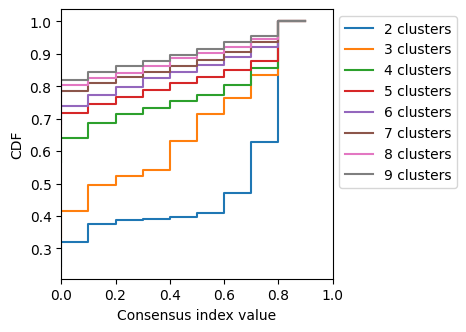

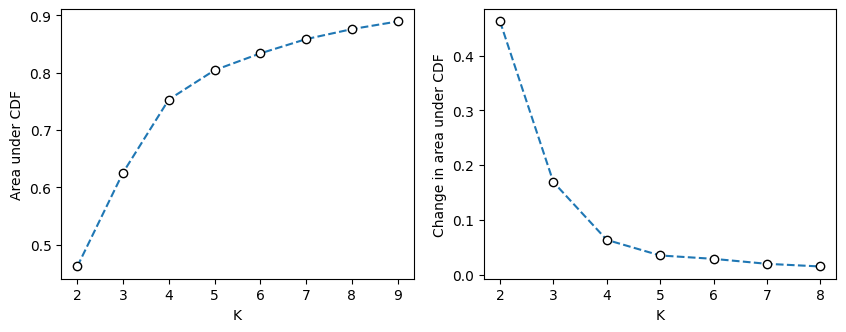

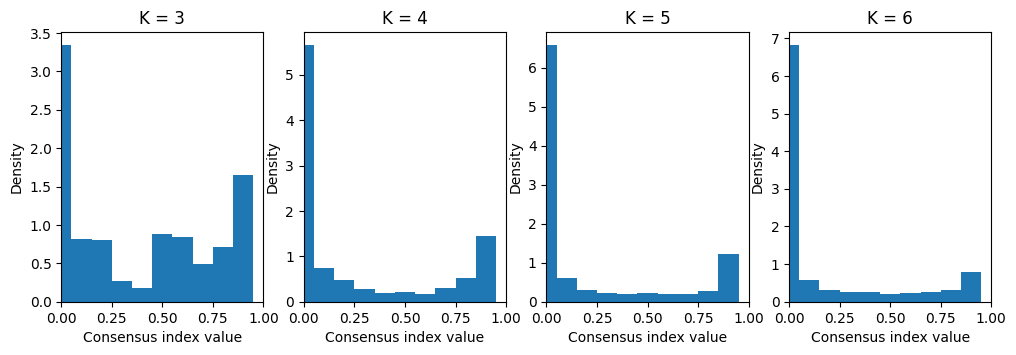

Best k from change in AUC: 2, and from AUC knee point: 4
Initial feature.shape: (2174, 429)
After VIF and dropping highly correlated features, feature.shape: (2174, 272)


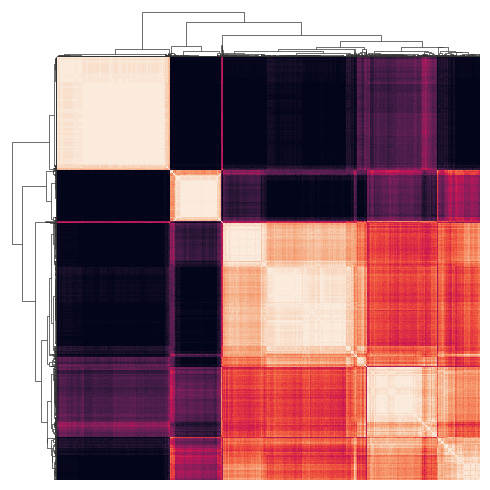

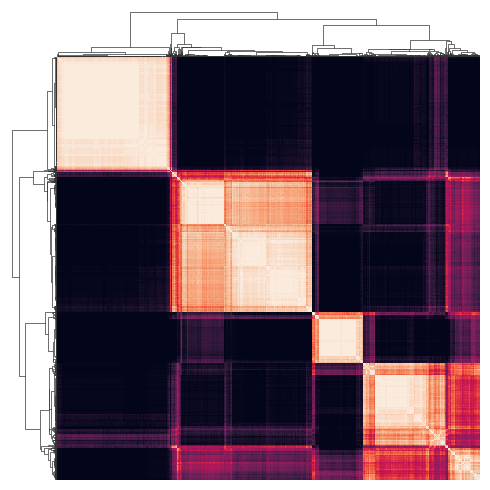

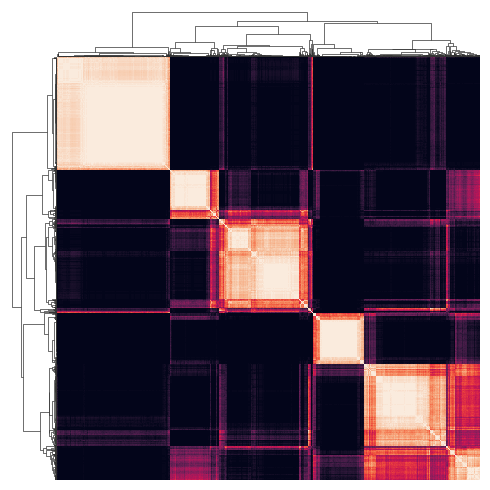

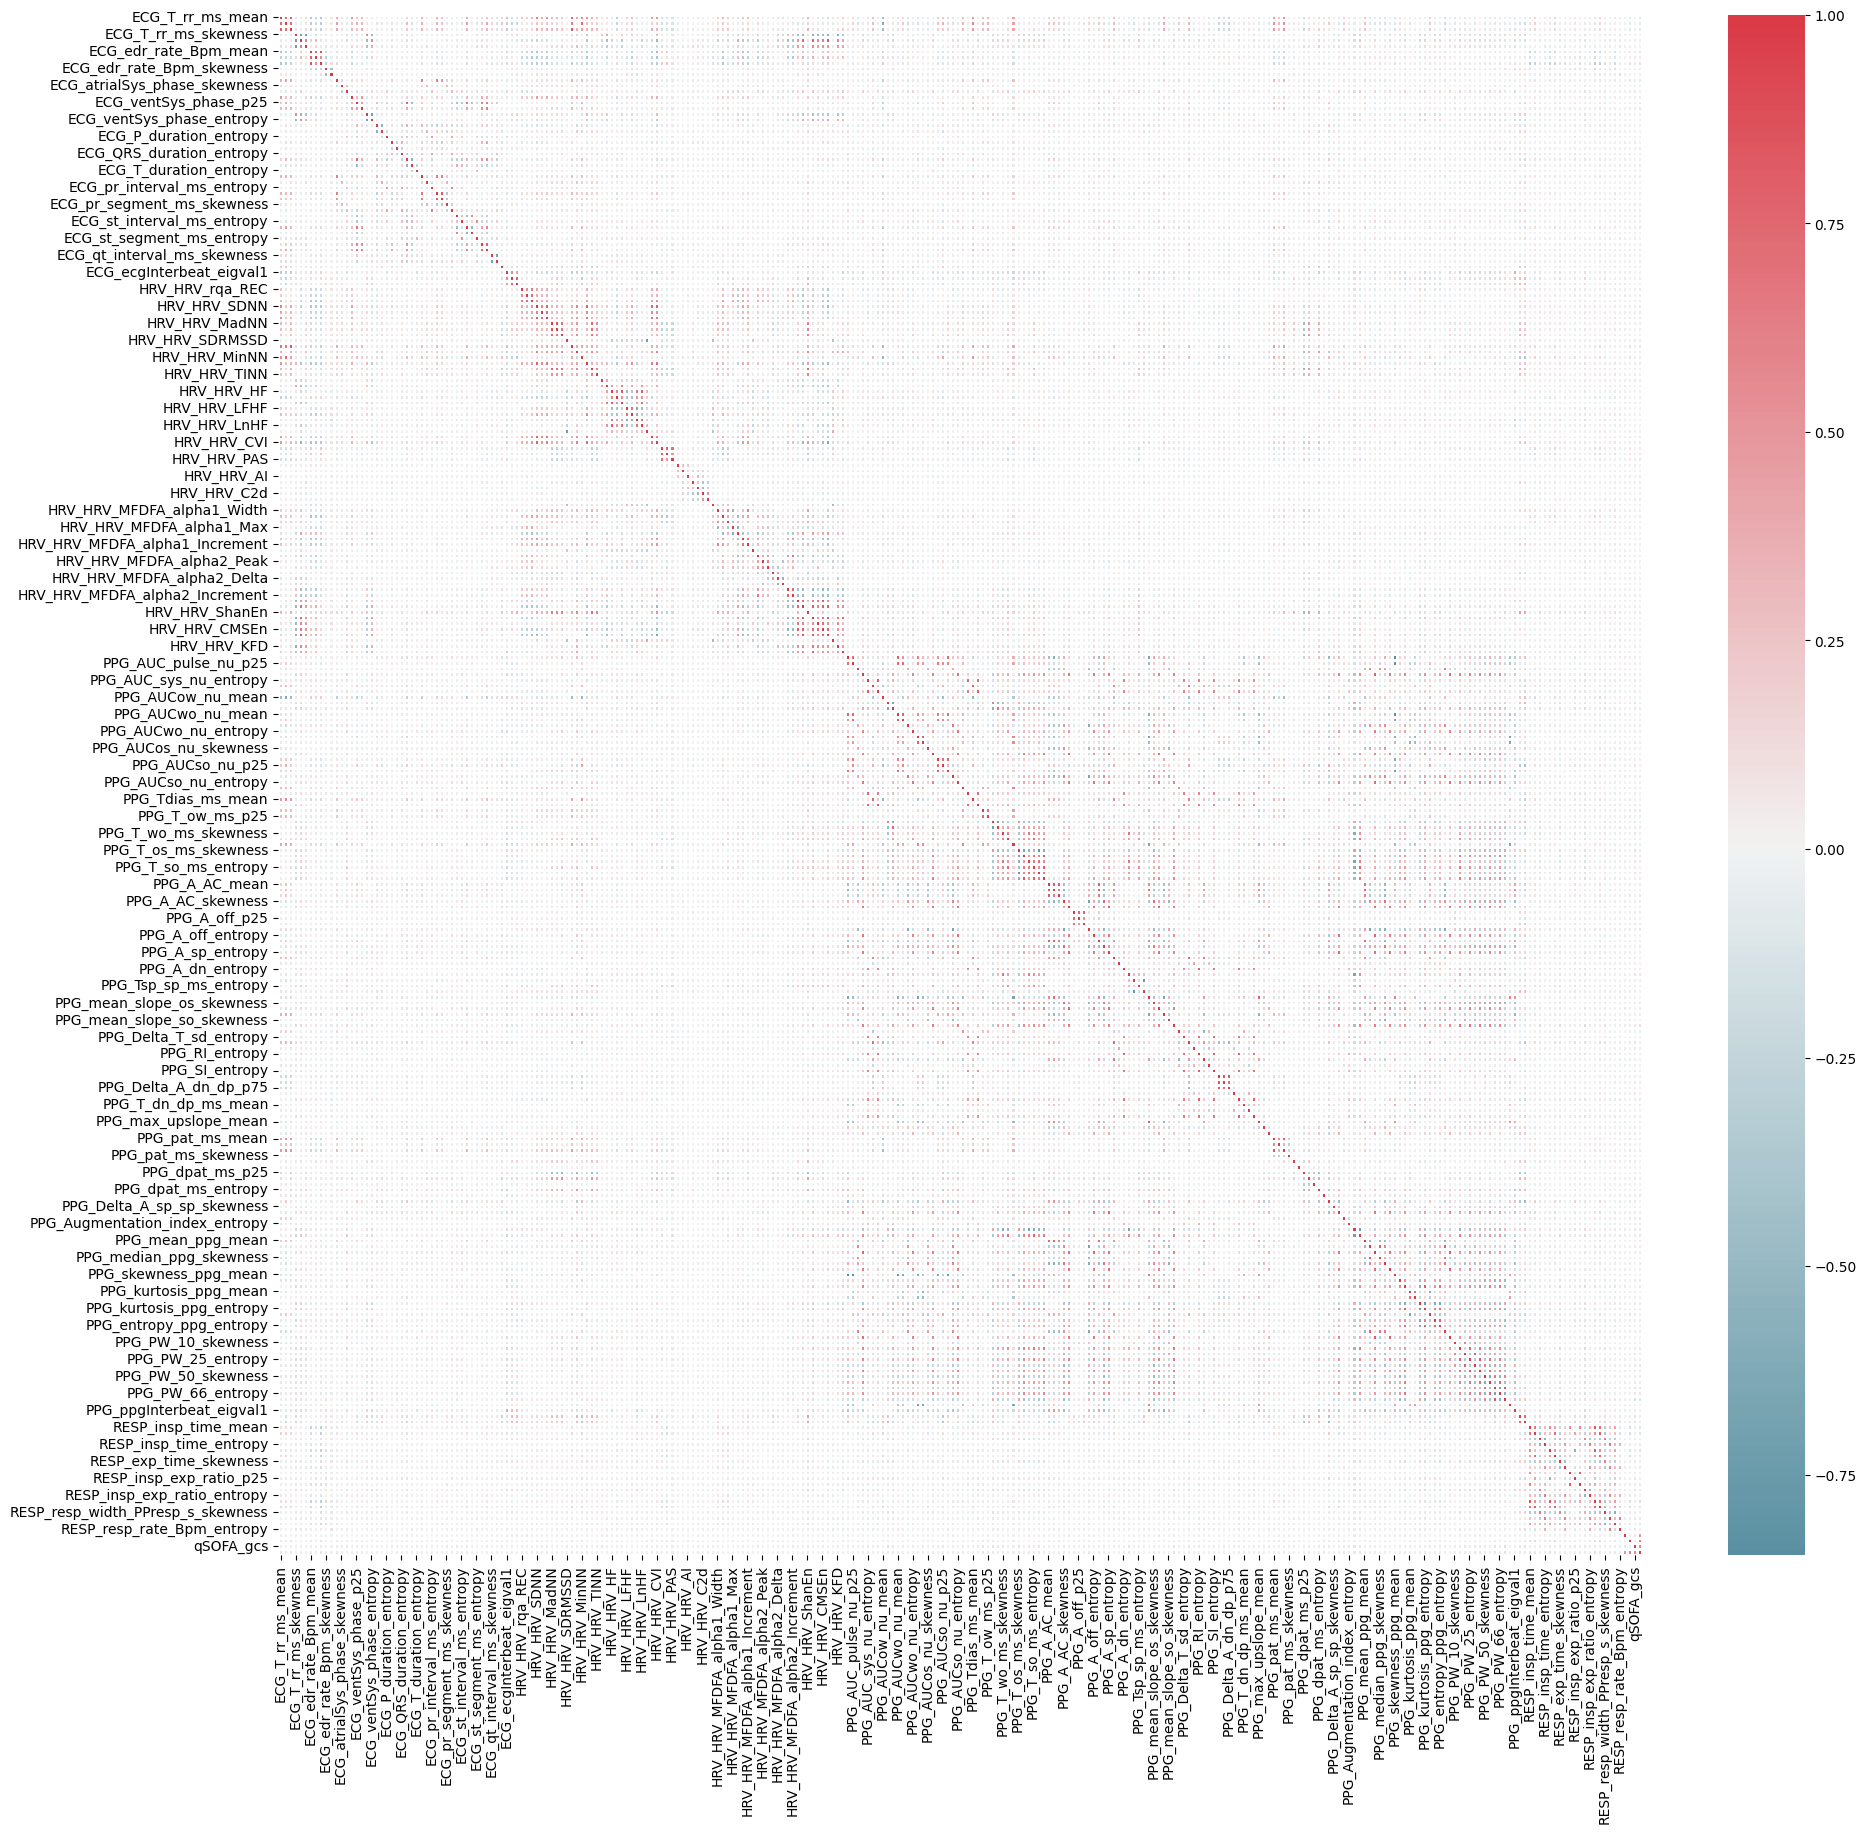

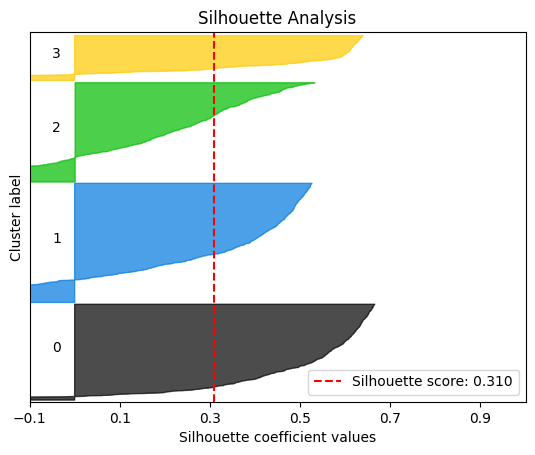

SS, DB, CH: 0.31, 1.079, 1429.217
1    721
2    601
0    580
3    272
Name: count, dtype: int64


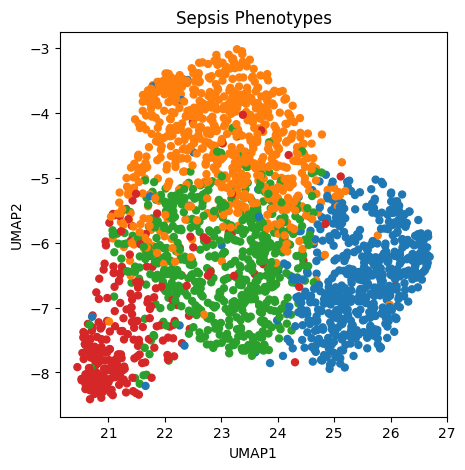

Shape of shap_values: (2174, 272, 4)
Shape of mean_abs_shap: (272,)
Length of sel_feature_list: 272
Number of features input to the model: 272
Train-test split: 1739 train, 435 test
Confusion matrix:
[[110   2   5   0]
 [  2 123  10   3]
 [  1   6 103   4]
 [  1   5   3  57]]
Overall accuracy: 0.903
Precision: [0.965 0.904 0.851 0.891]
Recall: [0.94  0.891 0.904 0.864]
F1-score: [0.952 0.898 0.877 0.877]
Accuracy per class: [0.94  0.891 0.904 0.864]
Predicted clusters on test set: Counter({1: 138, 0: 117, 2: 114, 3: 66})
selected feature list after filtering: 272

Top 5 features (overall):
               feature  importance
51        HRV_HRV_SDNN    0.654380
59       HRV_HRV_pNN50    0.455574
108      HRV_HRV_CMSEn    0.220828
109         HRV_HRV_CD    0.201565
156  PPG_A_AC_skewness    0.188178

Top 5 features per class:
Class 0:
                 feature  importance
51          HRV_HRV_SDNN    2.112195
68            HRV_HRV_TP    0.472663
4    ECG_T_rr_ms_entropy    0.435227
3   ECG_T

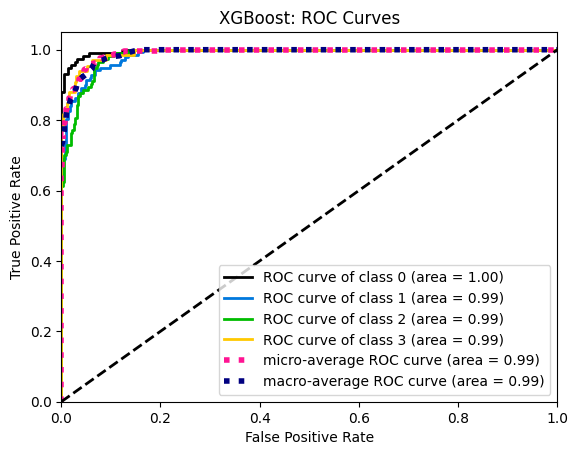

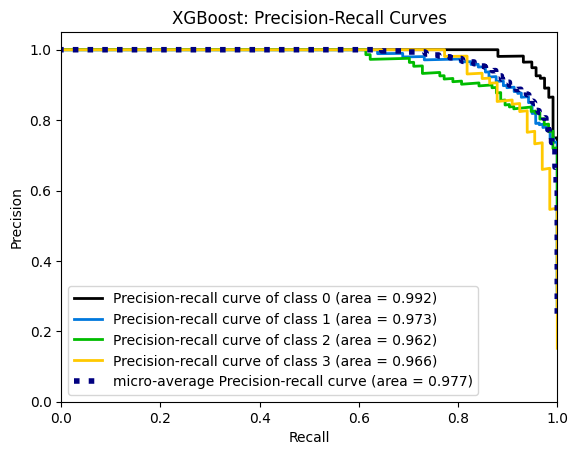

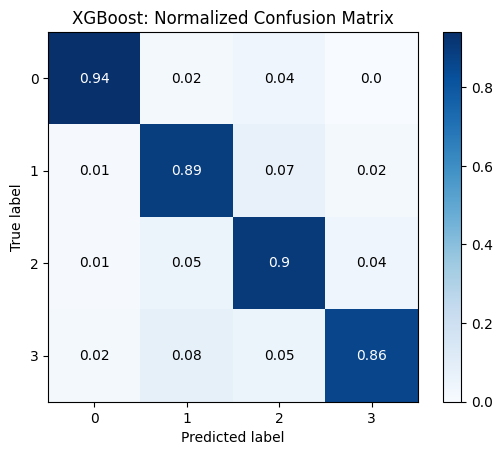

SHAP summary plot for phenotype 0


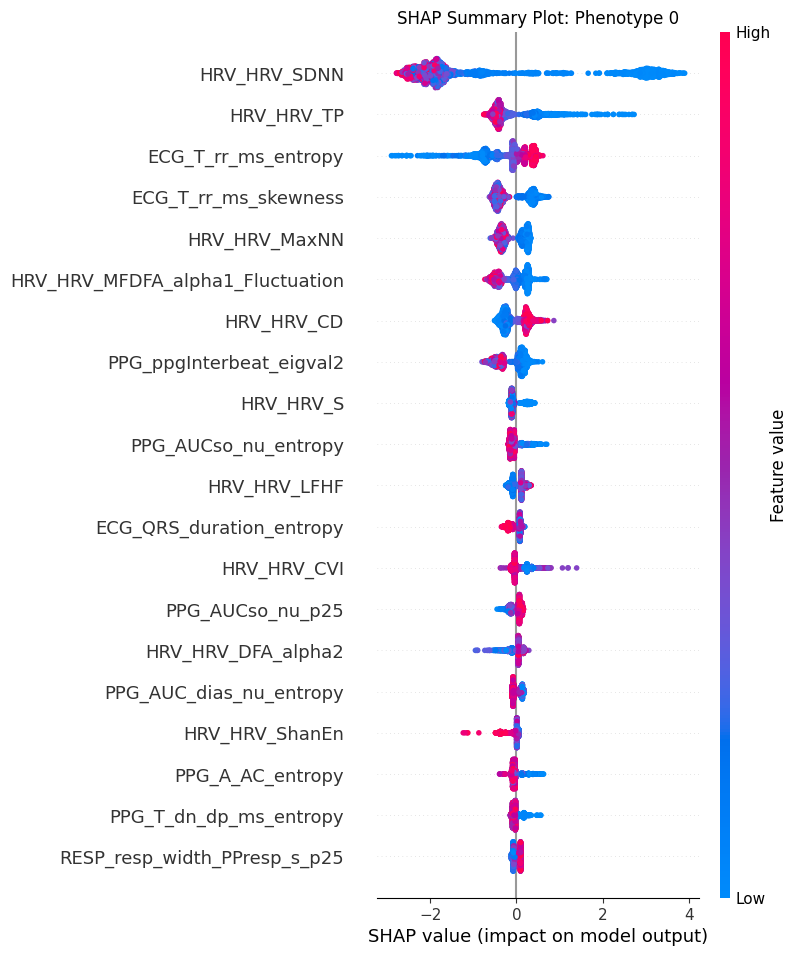

SHAP summary plot for phenotype 1


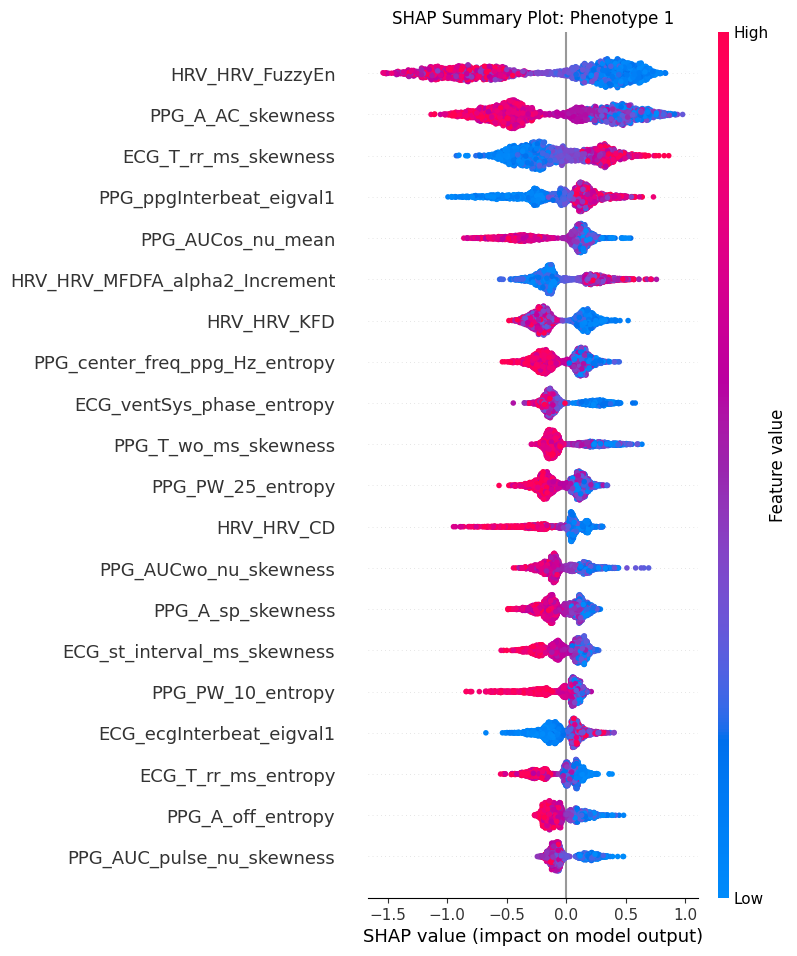

SHAP summary plot for phenotype 2


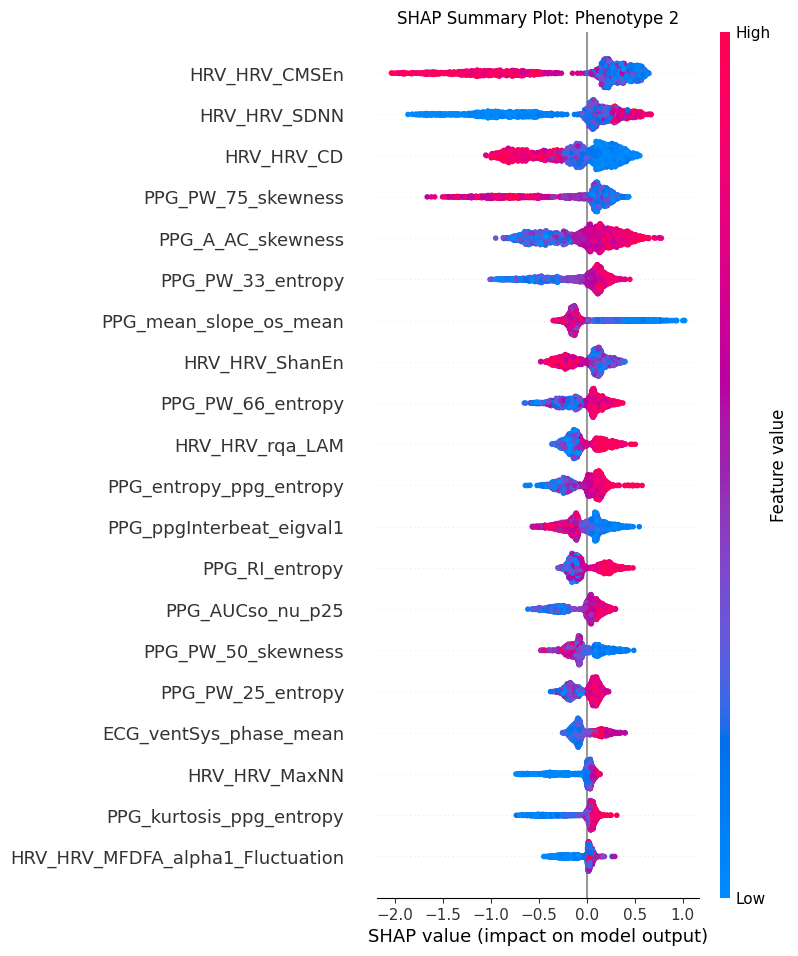

SHAP summary plot for phenotype 3


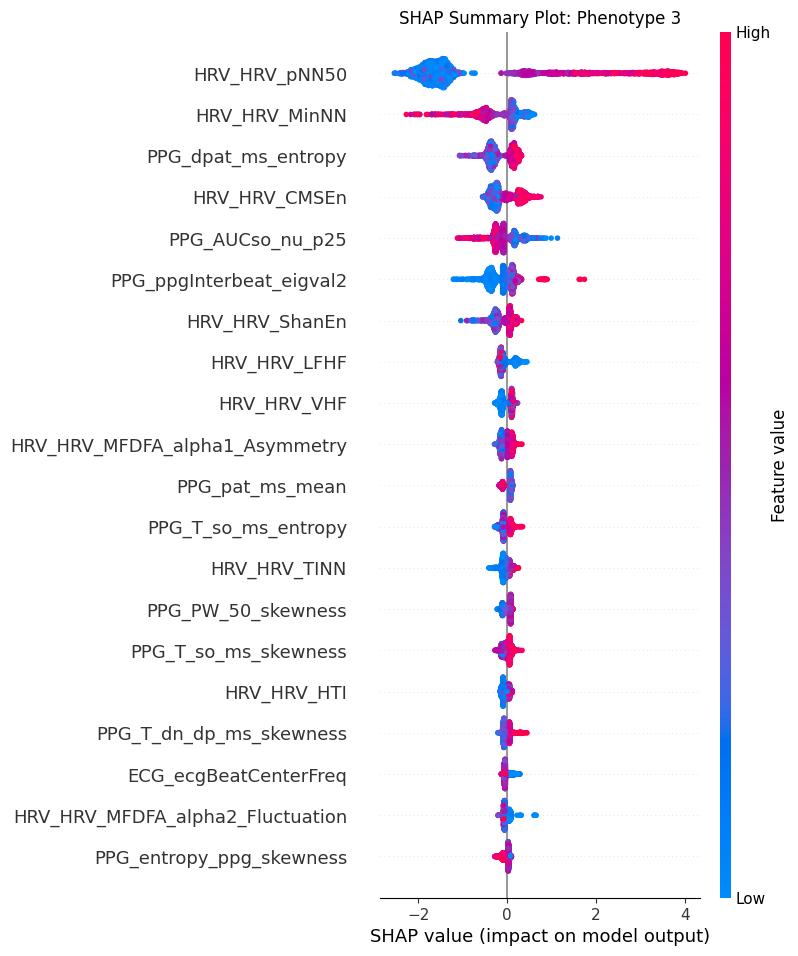

🔍 SHAP Values Debug Info:
Type: <class 'numpy.ndarray'>
Shape: (2174, 272, 4)
Number of dimensions: 3
Feature indices: 272 features
Sample feature indices: [('ECG_T_rr_ms_mean', 0), ('ECG_T_rr_ms_p25', 1), ('ECG_T_rr_ms_p75', 2), ('ECG_T_rr_ms_skewness', 3), ('ECG_T_rr_ms_entropy', 4)]
✅ Clustering complete: 4 phenotypes identified
   - 2174 patients analyzed
   - 272 features selected
   - Top SHAP features with mean absolute values per class: {0:                 feature  importance
0          HRV_HRV_SDNN    2.112195
1            HRV_HRV_TP    0.472663
2   ECG_T_rr_ms_entropy    0.435227
3  ECG_T_rr_ms_skewness    0.404202
4         HRV_HRV_MaxNN    0.286207, 1:                     feature  importance
0           HRV_HRV_FuzzyEn    0.577379
1         PPG_A_AC_skewness    0.462929
2      ECG_T_rr_ms_skewness    0.282121
3  PPG_ppgInterbeat_eigval1    0.226808
4         PPG_AUCos_nu_mean    0.220555, 2:               feature  importance
0       HRV_HRV_CMSEn    0.566837
1        HRV_HR

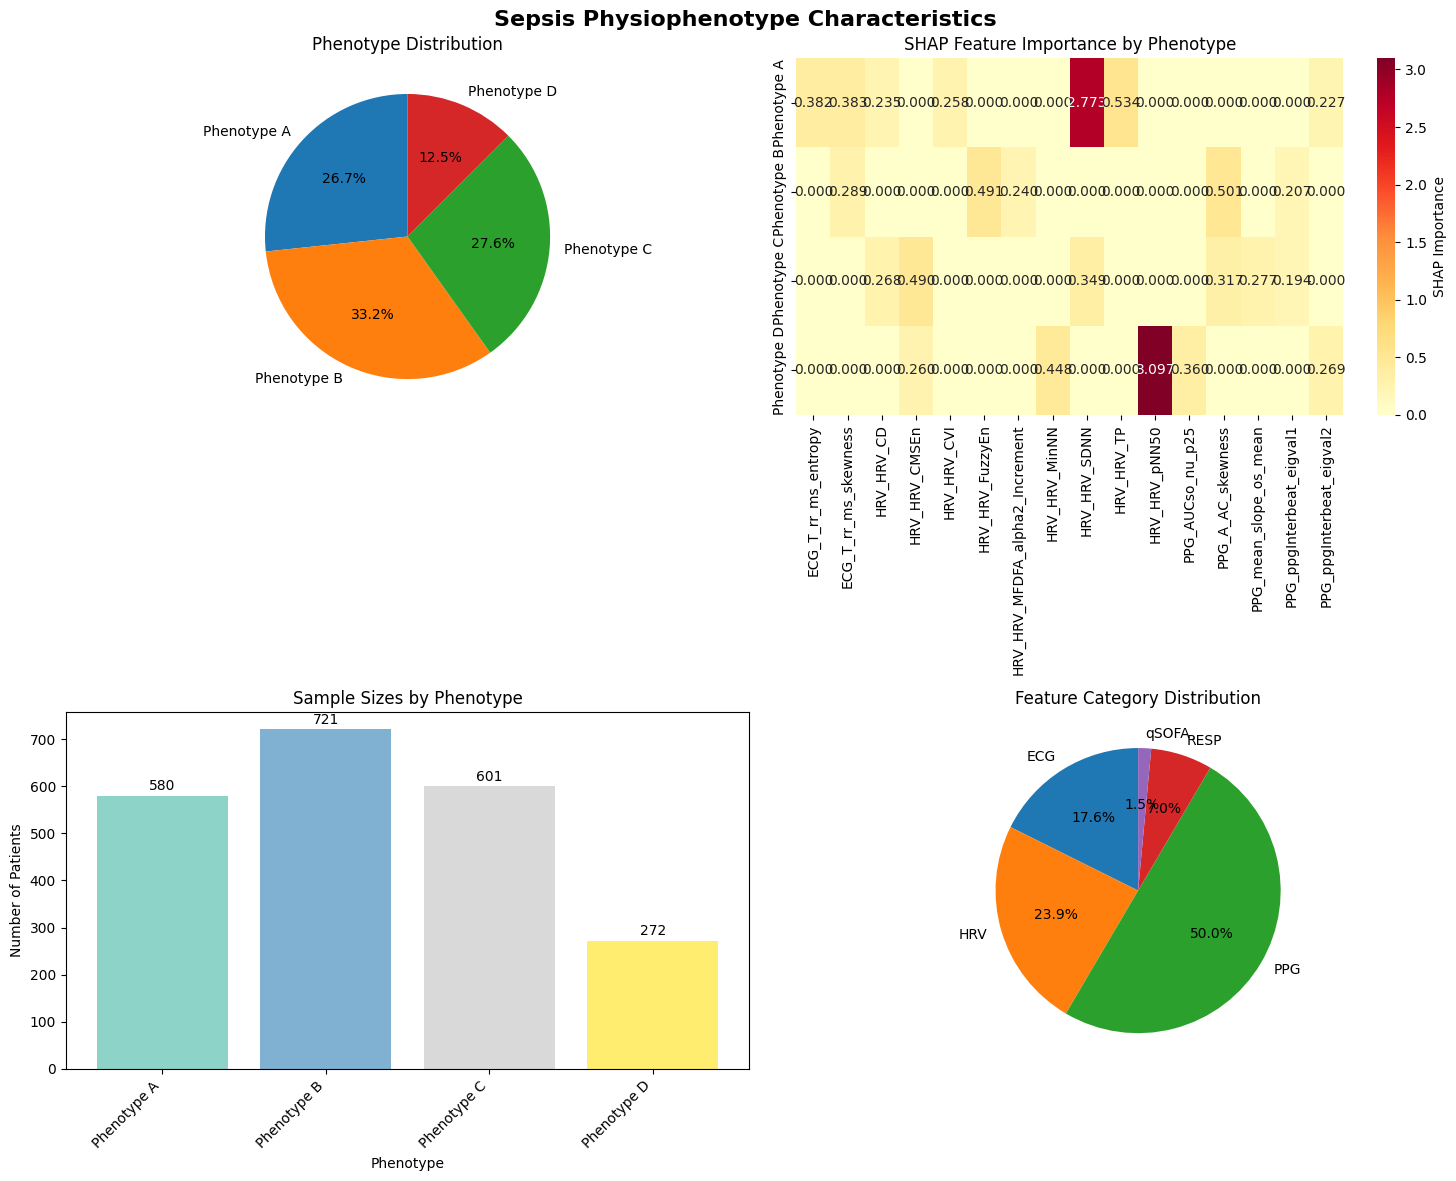

Results exported to: ./sepsis_phenotype_study_results/FTT_umap_latest/analysis_results/

SEPSIS PHENOTYPE ANALYSIS COMPLETE

Identified Sepsis Physiophenotypes:
• Cluster 0: Reduced Autonomic Variability with Cardiac Irregularity (580 patients, 26.7%)
• Cluster 1: Reduced Complexity with Altered Cardiac Rhythm (721 patients, 33.2%)
• Cluster 2: Reduced Complexity with Altered Pulse Dynamics (601 patients, 27.6%)
• Cluster 3: Enhanced Parasympathetic Complexity with Altered Perfusion (272 patients, 12.5%)

All results saved to: ./sepsis_phenotype_study_results/FTT_umap_latest/analysis_results/
✅ LLM interpretation complete
   - Phenotype names generated
   - Clinical interpretations created

📋 Step 3: Creating Analysis Summary...

💾 Step 4: Saving Results to ./sepsis_phenotype_study_results/FTT_umap_latest/analysis_results/
   ✅ Analysis summary: analysis_summary.json
   ✅ Cluster assignments: cluster_assignments.csv
   ✅ Selected features: selected_features.csv
   ✅ Trained model: trai

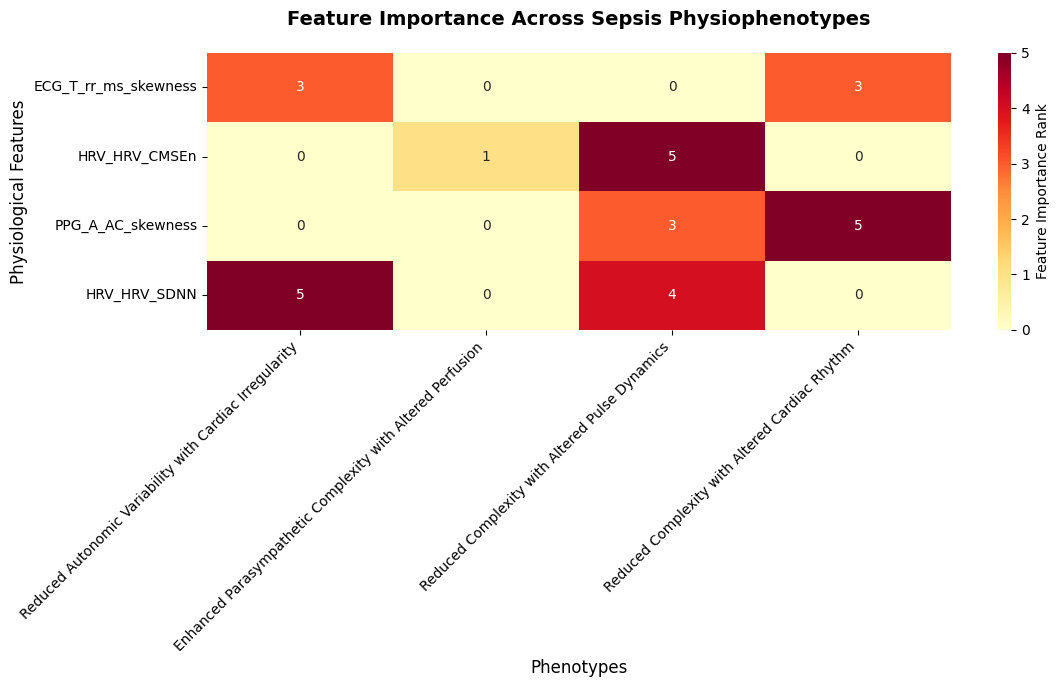

In [15]:
# 3. Run the complete workflow
results, validation_report, comparison_table, summary_cards = run_complete_sepsis_analysis_workflow(
    df_data=df_presepsis_5min,  # 2074 patients × 400+ features
    feature_columns=feature_cols,  # Your physiological features
    standard_minmax = 'standard',
    var_thresh = 0.01,
    corr_thresh = 0.85,
    dim_reduce_method = 'custom_embedding', 
    embedding_type = 'ftt_umap',
    k_opt = 4,
    verbose = 1, 
    api_provider = API_PROVIDER,
    api_key = API_KEY,
    model_name = MODEL_NAME,
    clinical_outcomes=None,  # Optional: mortality, LOS, etc. outcomes_data
    output_base_dir="./sepsis_phenotype_study_results/FTT_umap_latest"
)

# 4. Access the generated phenotype names
phenotype_names = results['phenotype_names']
print("Generated Sepsis Phenotype Names:")
for cluster_id, name in phenotype_names.items():
    print(f"  Cluster {cluster_id}: {name}")
    
    
import pickle
output_base_dir="./sepsis_phenotype_study_results/FTT_umap_latest"
with open(f"{output_base_dir}/results.pkl", "wb") as f:
    pickle.dump(results, f)
    
    
# with open(f"{output_base_dir}\results.pkl", "rb") as f:
#     results = pickle.load(f)

len(epochs),len(train_loss),len(val_loss):  120 120 120


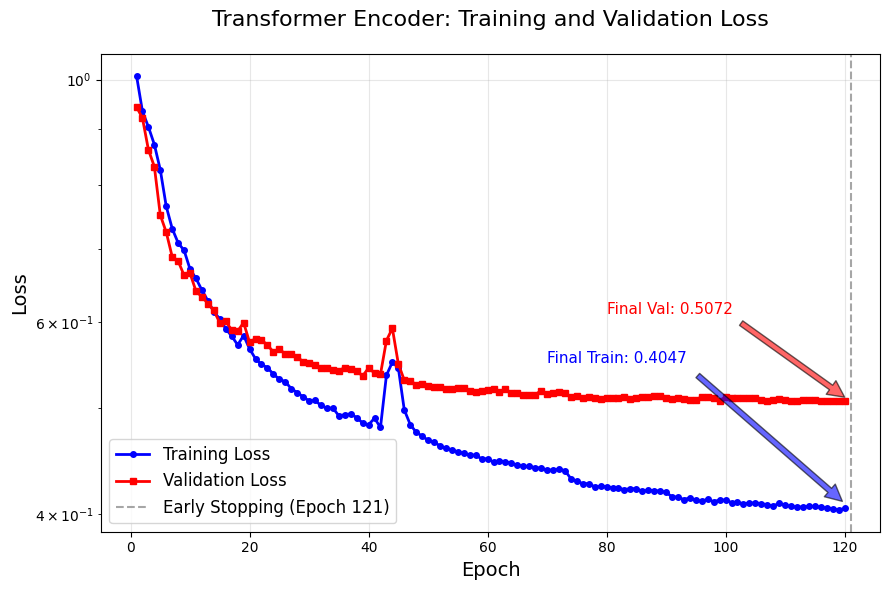

In [30]:
# Data from the training log


#Early Stopping Epoch
ese = 121

epochs = list(range(1, ese, 1))  # From 0 to 104 in steps of 1

train_loss = [
    1.0085, 0.9350, 0.9050, 0.8719, 0.8265, 0.7652, 0.7302, 0.7085, 0.6974, 0.6703,
    0.6574, 0.6412, 0.6271, 0.6125, 0.6037, 0.5911, 0.5821, 0.5714, 0.5828, 0.5667,
    0.5549, 0.5484, 0.5446, 0.5373, 0.5315, 0.5288, 0.5211, 0.5168, 0.5122, 0.5078,
    0.5082, 0.5030, 0.4998, 0.5002, 0.4921, 0.4931, 0.4941, 0.4902, 0.4847, 0.4828,
    0.4896, 0.4801, 0.5358, 0.5511, 0.5444, 0.4983, 0.4831, 0.4753, 0.4715, 0.4673,
    0.4654, 0.4619, 0.4593, 0.4582, 0.4560, 0.4546, 0.4528, 0.4530, 0.4493, 0.4495,
    0.4463, 0.4474, 0.4468, 0.4450, 0.4436, 0.4424, 0.4422, 0.4412, 0.4406, 0.4388,
    0.4389, 0.4397, 0.4384, 0.4310, 0.4287, 0.4265, 0.4265, 0.4236, 0.4239, 0.4238,
    0.4227, 0.4224, 0.4211, 0.4220, 0.4219, 0.4196, 0.4206, 0.4202, 0.4199, 0.4187,
    0.4148, 0.4145, 0.4123, 0.4139, 0.4116, 0.4109, 0.4127, 0.4105, 0.4120, 0.4119,
    0.4098, 0.4099, 0.4088, 0.4093, 0.4095, 0.4089, 0.4079, 0.4067, 0.4092, 0.4075,
    0.4064, 0.4060, 0.4059, 0.4066, 0.4064, 0.4057, 0.4052, 0.4046, 0.4034, 0.4047
]

val_loss = [
    0.9439, 0.9219, 0.8624, 0.8323, 0.7513, 0.7246, 0.6882, 0.6819, 0.6616, 0.6644,
    0.6400, 0.6323, 0.6235, 0.6144, 0.5985, 0.6004, 0.5897, 0.5883, 0.5989, 0.5745,
    0.5791, 0.5775, 0.5712, 0.5630, 0.5661, 0.5608, 0.5610, 0.5570, 0.5515, 0.5503,
    0.5472, 0.5441, 0.5438, 0.5424, 0.5412, 0.5447, 0.5431, 0.5411, 0.5351, 0.5443,
    0.5385, 0.5370, 0.5766, 0.5918, 0.5491, 0.5305, 0.5299, 0.5253, 0.5259, 0.5238,
    0.5232, 0.5229, 0.5208, 0.5205, 0.5214, 0.5217, 0.5190, 0.5170, 0.5187, 0.5196,
    0.5202, 0.5171, 0.5207, 0.5158, 0.5160, 0.5142, 0.5140, 0.5145, 0.5189, 0.5156,
    0.5166, 0.5178, 0.5165, 0.5116, 0.5132, 0.5106, 0.5116, 0.5105, 0.5101, 0.5113,
    0.5110, 0.5108, 0.5115, 0.5094, 0.5113, 0.5116, 0.5116, 0.5132, 0.5135, 0.5109,
    0.5095, 0.5105, 0.5098, 0.5086, 0.5089, 0.5123, 0.5116, 0.5110, 0.5080, 0.5120,
    0.5110, 0.5105, 0.5112, 0.5114, 0.5110, 0.5090, 0.5079, 0.5090, 0.5095, 0.5085,
    0.5077, 0.5079, 0.5090, 0.5084, 0.5087, 0.5079, 0.5080, 0.5076, 0.5075, 0.5072
]

learning_rate = [
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
    0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
    0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025,
    0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125,
    0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.0000625, 0.0000625, 0.0000625
]

print('len(epochs),len(train_loss),len(val_loss): ',len(epochs),len(train_loss),len(val_loss))

# Create the plot
plt.style.use('default')
plt.figure(figsize=(9, 6))
plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

# Add early stopping indicator
plt.axvline(x=ese, color='gray', linestyle='--', alpha=0.7, label=f'Early Stopping (Epoch {ese})')

# Customize the plot
plt.title('FT-Transformer Encoder: Training and Validation Loss', fontsize=16, pad=20)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visualization of small values

# Add annotations for final values
final_train = train_loss[-1]
final_val = val_loss[-1]
plt.annotate(f'Final Train: {final_train:.4f}', 
             xy=(ese, final_train), xytext=(70, 0.55),
             arrowprops=dict(facecolor='blue', shrink=0.05, alpha=0.6),
             fontsize=11, color='blue')

plt.annotate(f'Final Val: {final_val:.4f}', 
             xy=(ese, final_val), xytext=(80, 0.61),
             arrowprops=dict(facecolor='red', shrink=0.05, alpha=0.6),
             fontsize=11, color='red')

plt.tight_layout()
plt.show()

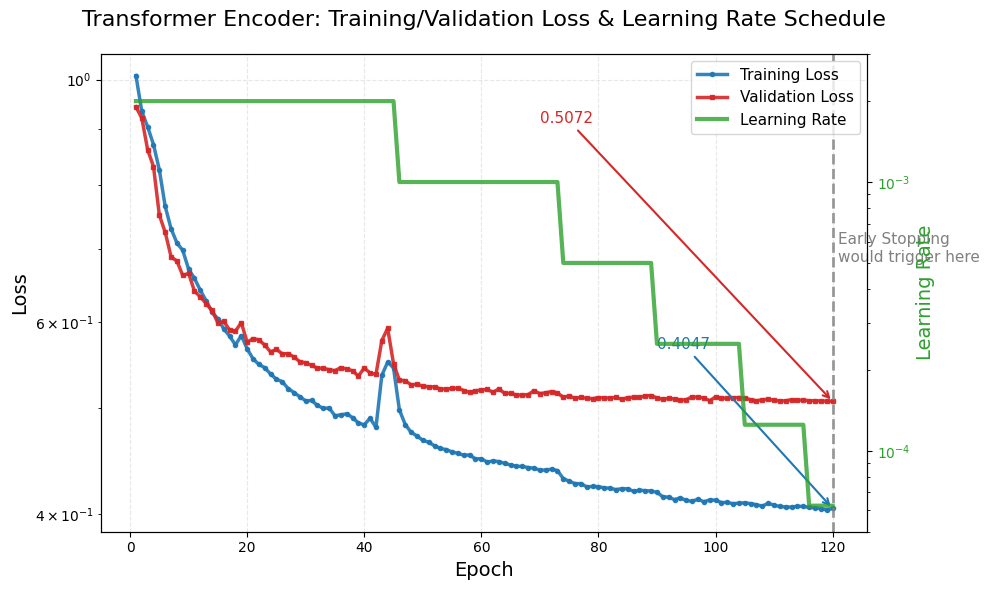

In [31]:

# Data
ese = 121
epochs = list(range(1, ese))  # 1 to 120
train_loss = [1.0085, 0.9350, 0.9050, 0.8719, 0.8265, 0.7652, 0.7302, 0.7085, 0.6974, 0.6703,
              0.6574, 0.6412, 0.6271, 0.6125, 0.6037, 0.5911, 0.5821, 0.5714, 0.5828, 0.5667,
              0.5549, 0.5484, 0.5446, 0.5373, 0.5315, 0.5288, 0.5211, 0.5168, 0.5122, 0.5078,
              0.5082, 0.5030, 0.4998, 0.5002, 0.4921, 0.4931, 0.4941, 0.4902, 0.4847, 0.4828,
              0.4896, 0.4801, 0.5358, 0.5511, 0.5444, 0.4983, 0.4831, 0.4753, 0.4715, 0.4673,
              0.4654, 0.4619, 0.4593, 0.4582, 0.4560, 0.4546, 0.4528, 0.4530, 0.4493, 0.4495,
              0.4463, 0.4474, 0.4468, 0.4450, 0.4436, 0.4424, 0.4422, 0.4412, 0.4406, 0.4388,
              0.4389, 0.4397, 0.4384, 0.4310, 0.4287, 0.4265, 0.4265, 0.4236, 0.4239, 0.4238,
              0.4227, 0.4224, 0.4211, 0.4220, 0.4219, 0.4196, 0.4206, 0.4202, 0.4199, 0.4187,
              0.4148, 0.4145, 0.4123, 0.4139, 0.4116, 0.4109, 0.4127, 0.4105, 0.4120, 0.4119,
              0.4098, 0.4099, 0.4088, 0.4093, 0.4095, 0.4089, 0.4079, 0.4067, 0.4092, 0.4075,
              0.4064, 0.4060, 0.4059, 0.4066, 0.4064, 0.4057, 0.4052, 0.4046, 0.4034, 0.4047]

val_loss = [0.9439, 0.9219, 0.8624, 0.8323, 0.7513, 0.7246, 0.6882, 0.6819, 0.6616, 0.6644,
            0.6400, 0.6323, 0.6235, 0.6144, 0.5985, 0.6004, 0.5897, 0.5883, 0.5989, 0.5745,
            0.5791, 0.5775, 0.5712, 0.5630, 0.5661, 0.5608, 0.5610, 0.5570, 0.5515, 0.5503,
            0.5472, 0.5441, 0.5438, 0.5424, 0.5412, 0.5447, 0.5431, 0.5411, 0.5351, 0.5443,
            0.5385, 0.5370, 0.5766, 0.5918, 0.5491, 0.5305, 0.5299, 0.5253, 0.5259, 0.5238,
            0.5232, 0.5229, 0.5208, 0.5205, 0.5214, 0.5217, 0.5190, 0.5170, 0.5187, 0.5196,
            0.5202, 0.5171, 0.5207, 0.5158, 0.5160, 0.5142, 0.5140, 0.5145, 0.5189, 0.5156,
            0.5166, 0.5178, 0.5165, 0.5116, 0.5132, 0.5106, 0.5116, 0.5105, 0.5101, 0.5113,
            0.5110, 0.5108, 0.5115, 0.5094, 0.5113, 0.5116, 0.5116, 0.5132, 0.5135, 0.5109,
            0.5095, 0.5105, 0.5098, 0.5086, 0.5089, 0.5123, 0.5116, 0.5110, 0.5080, 0.5120,
            0.5110, 0.5105, 0.5112, 0.5114, 0.5110, 0.5090, 0.5079, 0.5090, 0.5095, 0.5085,
            0.5077, 0.5079, 0.5090, 0.5084, 0.5087, 0.5079, 0.5080, 0.5076, 0.5075, 0.5072]

learning_rate = [0.0020]*45 + [0.0010]*28 + [0.0005]*16 + [0.00025]*15 + [0.000125]*11 + [0.0000625]*3
# Total: 45 + 28 + 16 + 15 + 11 + 3 = 118 → last 2 epochs stay at final LR
learning_rate += [0.0000625] * (120 - len(learning_rate))

# Plot
plt.style.use('default')
fig, ax1 = plt.subplots(figsize=(10, 6))

# Loss curves (left y-axis)
color_train = '#1f77b4'
color_val = '#d62728'
ax1.plot(epochs, train_loss, color=color_train, linewidth=2.5, label='Training Loss', marker='o', markersize=3, alpha=0.9)
ax1.plot(epochs, val_loss, color=color_val, linewidth=2.5, label='Validation Loss', marker='s', markersize=3, alpha=0.9)

ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Loss', fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, linestyle='--')

# Secondary y-axis for Learning Rate (right side)
ax2 = ax1.twinx()
color_lr = '#2ca02c'
ax2.plot(epochs, learning_rate, color=color_lr, linewidth=3, label='Learning Rate', alpha=0.8)
ax2.set_ylabel('Learning Rate', fontsize=14, color=color_lr)
ax2.tick_params(axis='y', labelcolor=color_lr)
ax2.set_yscale('log')
ax2.set_ylim(5e-5, 0.003)  # Nice range covering all LR values

# Title & legend
plt.title('Transformer Encoder: Training/Validation Loss & Learning Rate Schedule', fontsize=16, pad=20)

# Combine legends: Loss (from ax1) + LR (from ax2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

# Early stopping line
ax1.axvline(x=120, color='gray', linestyle='--', linewidth=2, alpha=0.8, label='Training End (Epoch 120)')
ax1.text(121, 0.7, 'Early Stopping\nwould trigger here', color='gray', fontsize=11, ha='left', va='center')

# Final value annotations
final_train = train_loss[-1]
final_val = val_loss[-1]
ax1.annotate(f'{final_train:.4f}', xy=(120, final_train), xytext=(90, final_train*1.4),
             arrowprops=dict(arrowstyle='->', color=color_train, lw=1.5), fontsize=11, color=color_train)
ax1.annotate(f'{final_val:.4f}', xy=(120, final_val), xytext=(70, final_val*1.8),
             arrowprops=dict(arrowstyle='->', color=color_val, lw=1.5), fontsize=11, color=color_val)

plt.tight_layout()
plt.show()

len(epochs), len(train_loss), len(val_loss), len(learning_rate):  120 120 120 120


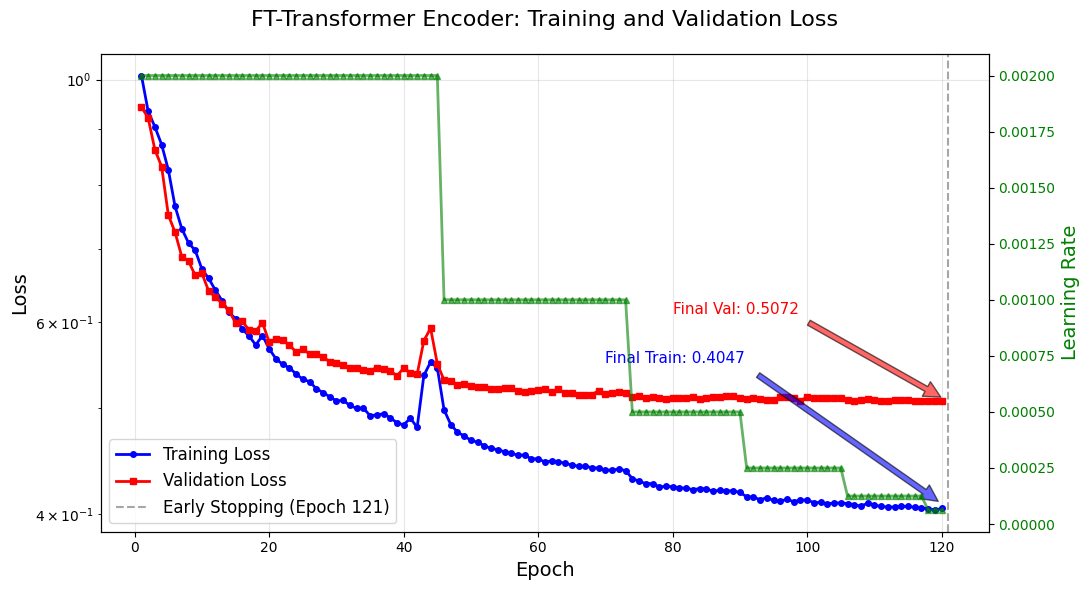

In [36]:
import matplotlib.pyplot as plt

# Data from the training log
ese = 121
epochs = list(range(1, ese, 1))  # From 1 to 120 in steps of 1
train_loss = [
    1.0085, 0.9350, 0.9050, 0.8719, 0.8265, 0.7652, 0.7302, 0.7085, 0.6974, 0.6703,
    0.6574, 0.6412, 0.6271, 0.6125, 0.6037, 0.5911, 0.5821, 0.5714, 0.5828, 0.5667,
    0.5549, 0.5484, 0.5446, 0.5373, 0.5315, 0.5288, 0.5211, 0.5168, 0.5122, 0.5078,
    0.5082, 0.5030, 0.4998, 0.5002, 0.4921, 0.4931, 0.4941, 0.4902, 0.4847, 0.4828,
    0.4896, 0.4801, 0.5358, 0.5511, 0.5444, 0.4983, 0.4831, 0.4753, 0.4715, 0.4673,
    0.4654, 0.4619, 0.4593, 0.4582, 0.4560, 0.4546, 0.4528, 0.4530, 0.4493, 0.4495,
    0.4463, 0.4474, 0.4468, 0.4450, 0.4436, 0.4424, 0.4422, 0.4412, 0.4406, 0.4388,
    0.4389, 0.4397, 0.4384, 0.4310, 0.4287, 0.4265, 0.4265, 0.4236, 0.4239, 0.4238,
    0.4227, 0.4224, 0.4211, 0.4220, 0.4219, 0.4196, 0.4206, 0.4202, 0.4199, 0.4187,
    0.4148, 0.4145, 0.4123, 0.4139, 0.4116, 0.4109, 0.4127, 0.4105, 0.4120, 0.4119,
    0.4098, 0.4099, 0.4088, 0.4093, 0.4095, 0.4089, 0.4079, 0.4067, 0.4092, 0.4075,
    0.4064, 0.4060, 0.4059, 0.4066, 0.4064, 0.4057, 0.4052, 0.4046, 0.4034, 0.4047
]
val_loss = [
    0.9439, 0.9219, 0.8624, 0.8323, 0.7513, 0.7246, 0.6882, 0.6819, 0.6616, 0.6644,
    0.6400, 0.6323, 0.6235, 0.6144, 0.5985, 0.6004, 0.5897, 0.5883, 0.5989, 0.5745,
    0.5791, 0.5775, 0.5712, 0.5630, 0.5661, 0.5608, 0.5610, 0.5570, 0.5515, 0.5503,
    0.5472, 0.5441, 0.5438, 0.5424, 0.5412, 0.5447, 0.5431, 0.5411, 0.5351, 0.5443,
    0.5385, 0.5370, 0.5766, 0.5918, 0.5491, 0.5305, 0.5299, 0.5253, 0.5259, 0.5238,
    0.5232, 0.5229, 0.5208, 0.5205, 0.5214, 0.5217, 0.5190, 0.5170, 0.5187, 0.5196,
    0.5202, 0.5171, 0.5207, 0.5158, 0.5160, 0.5142, 0.5140, 0.5145, 0.5189, 0.5156,
    0.5166, 0.5178, 0.5165, 0.5116, 0.5132, 0.5106, 0.5116, 0.5105, 0.5101, 0.5113,
    0.5110, 0.5108, 0.5115, 0.5094, 0.5113, 0.5116, 0.5116, 0.5132, 0.5135, 0.5109,
    0.5095, 0.5105, 0.5098, 0.5086, 0.5089, 0.5123, 0.5116, 0.5110, 0.5080, 0.5120,
    0.5110, 0.5105, 0.5112, 0.5114, 0.5110, 0.5090, 0.5079, 0.5090, 0.5095, 0.5085,
    0.5077, 0.5079, 0.5090, 0.5084, 0.5087, 0.5079, 0.5080, 0.5076, 0.5075, 0.5072
]
learning_rate = [
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0020,
    0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
    0.0010, 0.0010, 0.0010, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
    0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005,
    0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.00025,
    0.00025, 0.00025, 0.00025, 0.00025, 0.00025, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125,
    0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.000125, 0.0000625, 0.0000625, 0.0000625
]

# Check the lengths
print('len(epochs), len(train_loss), len(val_loss), len(learning_rate): ', len(epochs), len(train_loss), len(val_loss), len(learning_rate))

# Create the plot
fig, ax1 = plt.subplots(figsize=(11, 6))

# Plot the training and validation loss
ax1.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

# Add early stopping indicator
ax1.axvline(x=ese, color='gray', linestyle='--', alpha=0.7, label=f'Early Stopping (Epoch {ese})')

# Customize the left axis
ax1.set_title('FT-Transformer Encoder: Training and Validation Loss', fontsize=16, pad=20)
ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Loss', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Use log scale for better visualization of small values

# Add annotations for final values
final_train = train_loss[-1]
final_val = val_loss[-1]
ax1.annotate(f'Final Train: {final_train:.4f}', xy=(ese, final_train), xytext=(70, 0.55),
             arrowprops=dict(facecolor='blue', shrink=0.05, alpha=0.6), fontsize=11, color='blue')
ax1.annotate(f'Final Val: {final_val:.4f}', xy=(ese, final_val), xytext=(80, 0.61),
             arrowprops=dict(facecolor='red', shrink=0.05, alpha=0.6), fontsize=11, color='red')

# Create a secondary axis for the learning rate
ax2 = ax1.twinx()
ax2.plot(epochs, learning_rate, 'g-', label='Learning Rate', linewidth=2, marker='^', markersize=4, alpha=0.6)
ax2.set_ylabel('Learning Rate', fontsize=14, color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Tight layout and show the plot
fig.tight_layout()
plt.show()


LLM CLINICAL INTERPRETATION:
### 1. PHENOTYPE A NAME:
"Reduced Autonomic Variability with Cardiac Irregularity"

### 2. PATHOPHYSIOLOGICAL INTERPRETATION:
- **Sepsis Mechanisms:**
  - The pattern of lower HRV metrics (e.g., HRV_HRV_SDNN, HRV_HRV_TP, HRV_HRV_CVI) suggests significant autonomic dysfunction, likely due to sepsis-induced stress and inflammation affecting the autonomic nervous system. This is indicative of impaired autonomic regulation and a reduced ability to adapt to physiological stressors.
  - The higher entropy in RR intervals (ECG_T_rr_ms_entropy) alongside lower skewness (ECG_T_rr_ms_skewness) suggests irregular heart rhythms, potentially due to sepsis-induced myocardial dysfunction or arrhythmias.
  - The increased chaos index (HRV_HRV_CD) further supports the presence of cardiac electrical instability.

- **Affected Organ Systems:**
  - **Cardiovascular System:** The combination of reduced HRV and irregular heart rhythms points to significant cardiovascular compromise, likely involving both autonomic dysregulation and direct myocardial effects.
  - **Autonomic Nervous System:** The reduced HRV metrics indicate a blunted autonomic response, with potential dominance of sympathetic over parasympathetic activity.

- **Autonomic Function Pattern:**
  - The specific HRV metrics suggest a state of autonomic imbalance, characterized by reduced parasympathetic (vagal) activity and potentially increased sympathetic tone, reflecting a stress response to sepsis.

### 3. CLINICAL CHARACTERISTICS:
- **Clinical Presentation:**
  - Patients in this phenotype may present with signs of autonomic instability, such as tachycardia, irregular heartbeats, and possibly arrhythmias.
  - They may exhibit symptoms of cardiovascular compromise, including hypotension or signs of distributive shock.

- **Hemodynamic Profile:**
  - Likely to show signs of hemodynamic instability, with potential for low blood pressure and poor perfusion due to reduced vascular tone and cardiac output.

- **Respiratory Patterns:**
  - Patients may exhibit compensatory tachypnea as a response to metabolic acidosis or hypoperfusion, although specific respiratory features are not highlighted in this cluster.


### 1. PHENOTYPE B NAME:
"Reduced Complexity with Altered Cardiac Rhythm"

### 2. PATHOPHYSIOLOGICAL INTERPRETATION:
- **Sepsis Mechanisms:**
  - The pattern of lower HRV metrics such as Fuzzy Entropy and Katz Fractal Dimension suggests significant autonomic dysfunction, likely due to impaired autonomic regulation and increased physiological stress. This is common in sepsis, where systemic inflammation and stress responses disrupt normal autonomic balance.
  - Higher skewness in RR intervals indicates irregular heart rhythms, which may reflect sepsis-induced cardiomyopathy or arrhythmias, contributing to cardiovascular instability.
  - Lower PPG features such as AC skewness and AUC onset to shoulder suggest compromised peripheral circulation and reduced vascular tone, indicative of hemodynamic instability and potential distributive shock.

- **Affected Organ Systems:**
  - **Cardiovascular System:** The combination of altered HRV and ECG features points to significant cardiovascular compromise, including potential arrhythmias and impaired contractility.
  - **Autonomic Nervous System:** The reduced complexity in HRV metrics indicates autonomic dysfunction, a hallmark of sepsis pathophysiology.
  - **Peripheral Circulation:** Lower PPG features suggest impaired perfusion and vascular tone, affecting microcirculatory function.

- **Autonomic Function Pattern:**
  - The specific HRV metrics indicate a state of autonomic imbalance with reduced complexity, suggesting a shift towards sympathetic dominance or reduced parasympathetic activity, common in sepsis-related stress responses.

### 3. CLINICAL CHARACTERISTICS:
- **Clinical Presentation:**
  - Patients may present with signs of cardiovascular instability, such as arrhythmias or irregular heartbeats, and symptoms of poor peripheral perfusion, such as cool extremities or delayed capillary refill.
  
- **Hemodynamic Profile:**
  - Expect signs of distributive shock, including hypotension and reduced vascular resistance, potentially requiring vasopressor support.

- **Respiratory Patterns:**
  - While specific respiratory features are not highlighted, compensatory tachypnea may be present as a response to metabolic acidosis or hypoperfusion.


### 1. PHENOTYPE C NAME:
"Reduced Complexity with Altered Pulse Dynamics"

### 2. PATHOPHYSIOLOGICAL INTERPRETATION:
- **Sepsis Mechanisms:**
  - The pattern of lower HRV complexity measures (HRV_HRV_CMSEn, HRV_HRV_CD, HRV_HRV_ShanEn) suggests significant autonomic dysfunction, likely due to impaired autonomic regulation and increased physiological stress. This is common in sepsis, where systemic inflammation and stress responses disrupt normal autonomic control.
  - Higher HRV_HRV_SDNN indicates a paradoxical increase in overall HRV, which might reflect compensatory autonomic responses or variability due to arrhythmias.
  - Altered PPG features (e.g., increased PPG_A_AC_skewness and decreased PPG_mean_slope_os_mean) suggest changes in peripheral circulation, possibly due to vasodilation and altered arterial stiffness, common in sepsis-induced hemodynamic instability.

- **Affected Organ Systems:**
  - **Cardiovascular System:** The combination of HRV and PPG changes indicates significant cardiovascular involvement, with potential impacts on heart rate variability and peripheral perfusion.
  - **Autonomic Nervous System:** The reduced complexity in HRV metrics points to autonomic dysregulation, a hallmark of sepsis pathophysiology.

- **Autonomic Function Pattern:**
  - The specific HRV pattern, with reduced complexity and increased SDNN, suggests a state of autonomic imbalance where compensatory mechanisms are active but potentially overwhelmed by systemic stress and inflammation.

### 3. CLINICAL CHARACTERISTICS:
- **Clinical Presentation:**
  - Patients may present with signs of autonomic dysfunction, such as tachycardia, and potentially arrhythmias due to the altered HRV metrics.
  - Peripheral signs might include altered pulse strength and variability, reflecting changes in vascular tone and perfusion.

- **Hemodynamic Profile:**
  - Expect hemodynamic instability characterized by potential hypotension due to vasodilation and altered vascular resistance.
  - The increased pulse amplitude skewness suggests variability in pulse strength, possibly indicating fluctuating perfusion pressures.

- **Respiratory Patterns:**
  - Respiratory patterns may include compensatory tachypnea, as the body attempts to manage oxygen delivery and CO2 clearance in the face of systemic stress.


### 1. PHENOTYPE D NAME:
"Enhanced Parasympathetic Complexity with Altered Perfusion"

### 2. PATHOPHYSIOLOGICAL INTERPRETATION:
- **Sepsis Mechanisms:**
  - The pattern of higher HRV metrics such as HRV_HRV_pNN50, HRV_HRV_CMSEn, and HRV_HRV_ShanEn suggests an enhanced parasympathetic tone and increased complexity in heart rate variability. This may indicate a compensatory autonomic response to stress or early sepsis, where the body attempts to maintain homeostasis.
  - Lower HRV_HRV_LFHF indicates a reduced sympathetic activity relative to parasympathetic activity, which could reflect an imbalance in autonomic regulation often seen in sepsis.
  - The lower PPG_AUCso_nu_p25 and higher PPG_ppgInterbeat_eigval2 suggest altered peripheral perfusion and potential changes in arterial stiffness or vascular tone, possibly due to systemic inflammation and microcirculatory dysfunction.

- **Affected Organ Systems:**
  - **Autonomic Nervous System:** The HRV patterns indicate significant autonomic involvement, with a shift towards parasympathetic dominance.
  - **Cardiovascular System:** Altered PPG features suggest changes in peripheral circulation and potential hemodynamic instability.
  - **Microcirculation:** Impaired perfusion and vascular tone changes are suggested by PPG metrics.

- **Autonomic Function Pattern:**
  - The autonomic function pattern, characterized by higher parasympathetic activity and complexity, suggests a state of compensated autonomic perturbation. This may represent an early or stable phase of sepsis where the body is actively trying to counteract stressors.

### 3. CLINICAL CHARACTERISTICS:
- **Clinical Presentation:**
  - Patients may present with signs of autonomic imbalance, such as mild tachycardia or bradycardia, and potentially normal or slightly altered blood pressure due to compensatory mechanisms.
  - They might exhibit signs of altered perfusion, such as cool extremities or delayed capillary refill, despite normal vital signs.

- **Hemodynamic Profile:**
  - Expect a profile of relative hemodynamic stability with potential subtle signs of reduced vascular tone or early distributive shock.

- **Respiratory Patterns:**
  - Respiratory patterns may include mild tachypnea as a compensatory response, but without overt respiratory distress or failure at this stage.
